In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import cv2
import numpy as np
import shutil
RAW_PATH = "/content/drive/MyDrive/Stampede Prognosia/raw_images"
PRE_PATH = "/content/drive/MyDrive/Stampede Prognosia/preprocessed_images"
CAT_PATH = "/content/drive/MyDrive/Stampede Prognosia/categorized_images"


In [ ]:
#Resize & save images

import os
import cv2

RAW_PATH = "/content/drive/MyDrive/Stampede Prognosia/raw_images"
PRE_PATH = "/content/drive/MyDrive/Stampede Prognosia/preprocessed_images"

os.makedirs(PRE_PATH, exist_ok=True)

count = 0

for file in os.listdir(RAW_PATH):
    if file.lower().endswith(('.jpg','.jpeg','.png','.webp','.avif')):
        img_path = os.path.join(RAW_PATH, file)
        img = cv2.imread(img_path)

        if img is None:
            continue

        img = cv2.resize(img, (224, 224))
        save_path = os.path.join(PRE_PATH, file)

        cv2.imwrite(save_path, img)
        count += 1

print("Total preprocessed images saved:", count)


Total preprocessed images saved: 1217


# LABELING

In [ ]:
import numpy as np
import shutil

PRE_PATH = "/content/drive/MyDrive/Stampede Prognosia/preprocessed_images"
CAT_PATH = "/content/drive/MyDrive/Stampede Prognosia/categorized_images"

for cls in ["low", "medium", "high"]:
    os.makedirs(os.path.join(CAT_PATH, cls), exist_ok=True)


In [ ]:
def extract_features(img_path):
    img = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Reduce noise
    blur = cv2.GaussianBlur(gray, (5,5), 0)

    # Highlight people-like regions
    _, thresh = cv2.threshold(blur, 200, 255, cv2.THRESH_BINARY_INV)

    # Detect regions (approx people blobs)
    contours, _ = cv2.findContours(
        thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    people = [c for c in contours if cv2.contourArea(c) > 100]
    people_count = len(people)

    # Land area
    area = img.shape[0] * img.shape[1]
    density = people_count / area

    # How much area is occupied
    occupancy = np.sum(thresh > 0) / thresh.size

    # How tightly packed (edges)
    edges = cv2.Canny(gray, 50, 150)
    compactness = np.sum(edges > 0) / edges.size

    return density, occupancy, compactness


In [ ]:
features = []
filenames = []

for file in os.listdir(PRE_PATH):
    if file.lower().endswith(('.jpg','.jpeg','.png','.webp','.avif')):
        d, o, c = extract_features(os.path.join(PRE_PATH, file))
        features.append([d, o, c])
        filenames.append(file)

features = np.array(features)

In [ ]:
features_norm = (features - features.min(axis=0)) / (
    features.max(axis=0) - features.min(axis=0) + 1e-8
)


In [ ]:
congestion_score = features_norm.mean(axis=1)

In [ ]:
sorted_indices = np.argsort(congestion_score)

In [ ]:
n = len(sorted_indices)
low_cut = int(0.33 * n)
high_cut = int(0.66 * n)

labels = {}

for i, idx in enumerate(sorted_indices):
    if i < low_cut:
        labels[filenames[idx]] = "low"
    elif i < high_cut:
        labels[filenames[idx]] = "medium"
    else:
        labels[filenames[idx]] = "high"


In [ ]:
for file, label in labels.items():
    shutil.copy(
        os.path.join(PRE_PATH, file),
        os.path.join(CAT_PATH, label, file)
    )

print("Automatic labeling completed")


Automatic labeling completed


In [ ]:
for cls in ["low","medium","high"]:
    print(cls, ":", len(os.listdir(os.path.join(CAT_PATH, cls))))


low : 401
medium : 402
high : 414


# EDA

In [ ]:
import os

CAT_PATH = "/content/drive/MyDrive/Stampede Prognosia/categorized_images"

print("Folders inside categorized_images:")
print(os.listdir(CAT_PATH))


Folders inside categorized_images:
['high', 'low', 'medium']


In [ ]:
class_counts = {}

for cls in ["low", "medium", "high"]:
    count = len(os.listdir(os.path.join(CAT_PATH, cls)))
    class_counts[cls] = count
    print(cls, ":", count)


low : 401
medium : 402
high : 414


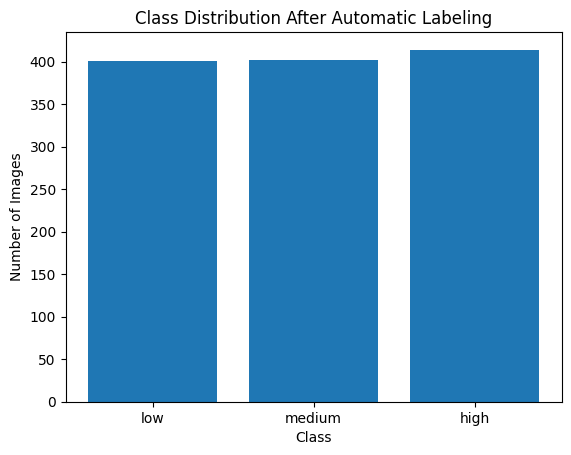

In [ ]:
import matplotlib.pyplot as plt

plt.bar(class_counts.keys(), class_counts.values())
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution After Automatic Labeling")
plt.show()

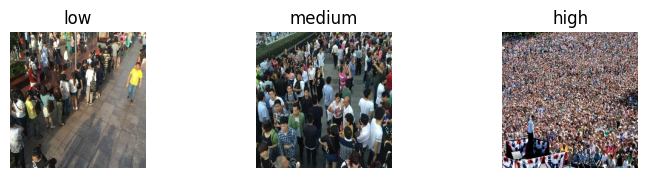

In [ ]:
import cv2
import random
import matplotlib.pyplot as plt

plt.figure(figsize=(9,6))
idx = 1

for cls in ["low", "medium", "high"]:
    images = random.sample(
        os.listdir(os.path.join(CAT_PATH, cls)),
        1
    )

    for img_name in images:
        img_path = os.path.join(CAT_PATH, cls, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(3,3,idx)
        plt.imshow(img)
        plt.title(cls)
        plt.axis("off")
        idx += 1

plt.show()


# DEEP LEARNING MODELS

80:20 Split


In [ ]:
import tensorflow as tf
import numpy as np
import random

SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

In [ ]:
#Common Data Generator

from tensorflow.keras.preprocessing.image import ImageDataGenerator

CAT_PATH = "/content/drive/MyDrive/Stampede Prognosia/categorized_images"

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest"
)

train_data = datagen.flow_from_directory(
    CAT_PATH,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=SEED
)

val_data = datagen.flow_from_directory(
    CAT_PATH,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=SEED
)

print("Training Samples:", train_data.samples)
print("Validation Samples:", val_data.samples)

Found 973 images belonging to 3 classes.
Found 242 images belonging to 3 classes.
Training Samples: 973
Validation Samples: 242


In [ ]:
#Class Weights

import numpy as np
from sklearn.utils.class_weight import compute_class_weight

y_classes = train_data.classes

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_classes),
    y=y_classes
)

class_weights = dict(enumerate(class_weights))
print(class_weights)


{0: np.float64(0.9828282828282828), 1: np.float64(1.0103842159916927), 2: np.float64(1.0072463768115942)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 257s 8s/step - accuracy: 0.5313 - loss: 3.4876 - val_accuracy: 0.3306 - val_loss: 5.8734
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 210s 7s/step - accuracy: 0.6051 - loss: 0.9338 - val_accuracy: 0.3306 - val_loss: 12.1429
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 264s 7s/step - accuracy: 0.6235 - loss: 0.7262 - val_accuracy: 0.3306 - val_loss: 18.2156
Epoch 4/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 222s 7s/step - accuracy: 0.6181 - loss: 0.7528 - val_accuracy: 0.3306 - val_loss: 24.3254
Epoch 5/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 217s 7s/step - accuracy: 0.5967 - loss: 0.7660 - val_accuracy: 0.3306 - val_loss: 29.8518
Epoch 6/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 223s 7s/step - accuracy: 0.6497 - loss: 0.7386 - val_accuracy: 0.3306 - val_loss: 32.3584
Epoch 7/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 211s 7s/step - accuracy: 0.6586 - loss: 0.7318 - val_accuracy: 0.3306 - val_loss: 35.2584
Epoch 8/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 208s 7s/step - accuracy: 0.6447 - loss: 0.7115 - val_accuracy: 0.33

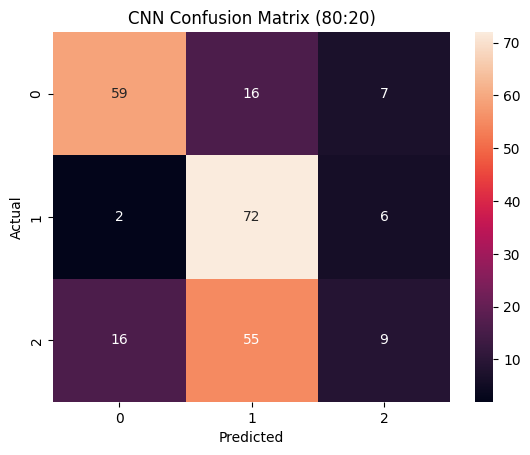

CNN model saved at: /content/drive/MyDrive/Stampede Prognosia/saved_models/cnn_stampede_80_20.h5


In [ ]:
#Model 1:CNN MODEL
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd


cnn_model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256,activation='relu'),
    Dropout(0.5),
    Dense(3,activation='softmax')
])

cnn_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# TRAIN (80:20 assumed already split)
history = cnn_model.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)

# Overall Training Accuracy
loss_train, acc_train = cnn_model.evaluate(train_data)
print("\nCNN Training Accuracy:", round(acc_train*100,2), "%")

# Validation Accuracy
loss_val, acc_val = cnn_model.evaluate(val_data)
print("CNN Validation Accuracy:", round(acc_val*100,2), "%")

# Predictions for metrics
y_true = val_data.classes
y_pred_probs = cnn_model.predict(val_data)
y_pred = np.argmax(y_pred_probs, axis=1)

# Evaluation Metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')
kappa = cohen_kappa_score(y_true, y_pred)

print("Accuracy:", round(accuracy*100,2), "%")
print("Precision:", round(precision,3))
print("Recall:", round(recall,3))
print("F1-Score:", round(f1,3))
print("Kappa:", round(kappa,3))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("CNN Confusion Matrix (80:20)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Save Model Permanently
MODEL_SAVE_PATH = "/content/drive/MyDrive/Stampede Prognosia/saved_models"
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

cnn_path = os.path.join(MODEL_SAVE_PATH, "cnn_stampede_80_20.h5")
cnn_model.save(cnn_path)

print("CNN model saved at:", cnn_path)



94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 332s 10s/step - accuracy: 0.4723 - loss: 1.0262 - val_accuracy: 0.3306 - val_loss: 1.1363
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 339s 11s/step - accuracy: 0.6442 - loss: 0.7233 - val_accuracy: 0.3264 - val_loss: 1.1310
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 308s 10s/step - accuracy: 0.6638 - loss: 0.7021 - val_accuracy: 0.3347 - val_loss: 1.1231
Epoch 4/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 320s 10s/step - accuracy: 0.7127 - loss: 0.6633 - val_accuracy: 0.3636 - val_loss: 1.1364
Epoch 5/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 304s 10s/step - accuracy: 0.6424 - loss: 0.7447 - val_accuracy: 0.3843 - val_loss: 1.1449
Epoch 6/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 305s 10s/step - accuracy: 0.7088 - loss: 0.6306 - val_accuracy: 0.3636 - val_loss: 1.3078
Epoch 7/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 322s 10s/step - accuracy: 0.6512 - loss: 0.6917 - val_accuracy: 0.3430 - val_loss: 1.3351
Epoch 8/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 309s 10s/step -

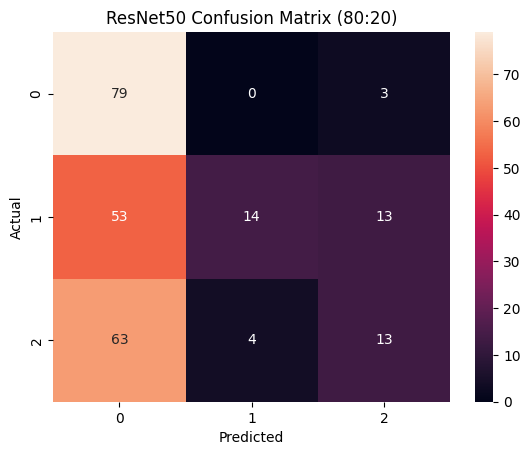

ResNet50 model saved at: /content/drive/MyDrive/Stampede Prognosia/saved_models/resnet50_stampede_80_20.h5


In [ ]:
#MODEL 2: RESNET50

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

# LOAD BASE MODEL
base = ResNet50(weights="imagenet",
                include_top=False,
                input_shape=(224,224,3))

# Freeze all except last 20 layers
for layer in base.layers[:-20]:
    layer.trainable = False

# BUILD MODEL
model_res = Sequential([
    base,
    GlobalAveragePooling2D(),
    Dense(256,activation="relu"),
    Dropout(0.5),
    Dense(3,activation="softmax")
])

model_res.compile(
    optimizer=Adam(0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# TRAIN (80:20 assumed already split)
history = model_res.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)

# TRAINING ACCURACY
loss_train, acc_train = model_res.evaluate(train_data)
print("\nResNet50 Training Accuracy:", round(acc_train*100,2), "%")

# VALIDATION ACCURACY
loss_val, acc_val = model_res.evaluate(val_data)
print("ResNet50 Validation Accuracy:", round(acc_val*100,2), "%")

# PREDICTIONS
y_true = val_data.classes
y_pred_probs = model_res.predict(val_data)
y_pred = np.argmax(y_pred_probs, axis=1)

# METRICS
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')
kappa = cohen_kappa_score(y_true, y_pred)

print("Accuracy:", round(accuracy*100,2), "%")
print("Precision:", round(precision,3))
print("Recall:", round(recall,3))
print("F1-Score:", round(f1,3))
print("Kappa:", round(kappa,3))

# CONFUSION MATRIX
cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("ResNet50 Confusion Matrix (80:20)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# SAVE MODEL PERMANENTLY
MODEL_SAVE_PATH = "/content/drive/MyDrive/Stampede Prognosia/saved_models"
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

res_path = os.path.join(MODEL_SAVE_PATH, "resnet50_stampede_80_20.h5")
model_res.save(res_path)

print("ResNet50 model saved at:", res_path)



29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 321s 10s/step - accuracy: 0.3839 - loss: 1.3543 - val_accuracy: 0.4917 - val_loss: 0.9911
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 212s 7s/step - accuracy: 0.5435 - loss: 0.9570 - val_accuracy: 0.4587 - val_loss: 1.0408
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 212s 7s/step - accuracy: 0.6003 - loss: 0.8454 - val_accuracy: 0.4835 - val_loss: 1.0119
Epoch 4/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 211s 7s/step - accuracy: 0.6043 - loss: 0.8204 - val_accuracy: 0.4793 - val_loss: 1.1161
Epoch 5/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 211s 7s/step - accuracy: 0.6423 - loss: 0.7580 - val_accuracy: 0.4587 - val_loss: 1.2244
Epoch 6/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 209s 7s/step - accuracy: 0.6627 - loss: 0.7089 - val_accuracy: 0.4628 - val_loss: 1.2824
Epoch 7/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 250s 8s/step - accuracy: 0.6774 - loss: 0.7005 - val_accuracy: 0.4463 - val_loss: 1.4484
Epoch 8/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 211s 7s/step - accuracy: 0.6759 - loss: 0.7059 - val_accuracy: 0.4669 - 

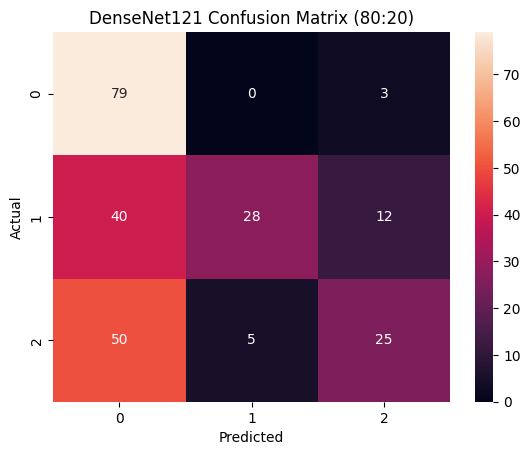

DenseNet121 model saved at: /content/drive/MyDrive/Stampede Prognosia/saved_models/densenet121_stampede_80_20.h5


In [ ]:
#MODEL 3: DenseNet121

from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

# LOAD BASE MODEL
base = DenseNet121(weights="imagenet",
                   include_top=False,
                   input_shape=(224,224,3))

# Freeze all except last 20 layers
for layer in base.layers[:-20]:
    layer.trainable = False

# BUILD MODEL
model_dense = Sequential([
    base,
    GlobalAveragePooling2D(),
    Dense(256,activation="relu"),
    Dropout(0.5),
    Dense(3,activation="softmax")
])

model_dense.compile(
    optimizer=Adam(0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# TRAIN (80:20 assumed already split)
history = model_dense.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)

# TRAINING ACCURACY
loss_train, acc_train = model_dense.evaluate(train_data)
print("\nDenseNet121 Training Accuracy:", round(acc_train*100,2), "%")

# VALIDATION ACCURACY
loss_val, acc_val = model_dense.evaluate(val_data)
print("DenseNet121 Validation Accuracy:", round(acc_val*100,2), "%")

# PREDICTIONS
y_true = val_data.classes
y_pred_probs = model_dense.predict(val_data)
y_pred = np.argmax(y_pred_probs, axis=1)

# METRICS
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')
kappa = cohen_kappa_score(y_true, y_pred)

print("Accuracy:", round(accuracy*100,2), "%")
print("Precision:", round(precision,3))
print("Recall:", round(recall,3))
print("F1-Score:", round(f1,3))
print("Kappa:", round(kappa,3))

# CONFUSION MATRIX
cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("DenseNet121 Confusion Matrix (80:20)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# SAVE MODEL PERMANENTLY
MODEL_SAVE_PATH = "/content/drive/MyDrive/Stampede Prognosia/saved_models"
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

dense_path = os.path.join(MODEL_SAVE_PATH, "densenet121_stampede_80_20.h5")
model_dense.save(dense_path)

print("DenseNet121 model saved at:", dense_path)



16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 124s 4s/step - accuracy: 0.3183 - loss: 1.1394 - val_accuracy: 0.3388 - val_loss: 1.1082
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 104s 3s/step - accuracy: 0.3914 - loss: 1.0877 - val_accuracy: 0.3388 - val_loss: 1.1097
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 104s 3s/step - accuracy: 0.4099 - loss: 1.0705 - val_accuracy: 0.3388 - val_loss: 1.1132
Epoch 4/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 103s 3s/step - accuracy: 0.4663 - loss: 1.0175 - val_accuracy: 0.3388 - val_loss: 1.1159
Epoch 5/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 103s 3s/step - accuracy: 0.5004 - loss: 1.0211 - val_accuracy: 0.3388 - val_loss: 1.1248
Epoch 6/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 104s 3s/step - accuracy: 0.5007 - loss: 0.9930 - val_accuracy: 0.3388 - val_loss: 1.1453
Epoch 7/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 103s 3s/step - accuracy: 0.4847 - loss: 0.9986 - val_accuracy: 0.3388 - val_loss: 1.1228
Epoch 8/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 103s 3s/step - accurac

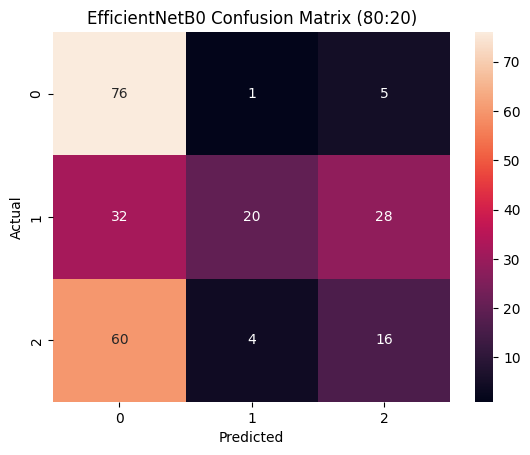

EfficientNetB0 model saved at: /content/drive/MyDrive/Stampede Prognosia/saved_models/efficientnetb0_stampede_80_20.h5


In [ ]:
#MODEL 4: EfficientNetB0

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

# LOAD BASE MODEL
base = EfficientNetB0(weights="imagenet",
                      include_top=False,
                      input_shape=(224,224,3))

# Freeze all except last 20 layers
for layer in base.layers[:-20]:
    layer.trainable = False

# BUILD MODEL
model_eff = Sequential([
    base,
    GlobalAveragePooling2D(),
    Dense(256,activation="relu"),
    Dropout(0.5),
    Dense(3,activation="softmax")
])

model_eff.compile(
    optimizer=Adam(0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# TRAIN (80:20 assumed already split)
history = model_eff.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)

# TRAINING ACCURACY
loss_train, acc_train = model_eff.evaluate(train_data)
print("\nEfficientNetB0 Training Accuracy:", round(acc_train*100,2), "%")

# VALIDATION ACCURACY
loss_val, acc_val = model_eff.evaluate(val_data)
print("EfficientNetB0 Validation Accuracy:", round(acc_val*100,2), "%")

# PREDICTIONS
y_true = val_data.classes
y_pred_probs = model_eff.predict(val_data)
y_pred = np.argmax(y_pred_probs, axis=1)

# METRICS
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')
kappa = cohen_kappa_score(y_true, y_pred)

print("Accuracy:", round(accuracy*100,2), "%")
print("Precision:", round(precision,3))
print("Recall:", round(recall,3))
print("F1-Score:", round(f1,3))
print("Kappa:", round(kappa,3))

# CONFUSION MATRIX
cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("EfficientNetB0 Confusion Matrix (80:20)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# SAVE MODEL PERMANENTLY
MODEL_SAVE_PATH = "/content/drive/MyDrive/Stampede Prognosia/saved_models"
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

eff_path = os.path.join(MODEL_SAVE_PATH, "efficientnetb0_stampede_80_20.h5")
model_eff.save(eff_path)

print("EfficientNetB0 model saved at:", eff_path)



Found 973 images belonging to 3 classes.
Found 242 images belonging to 3 classes.
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 445s 14s/step - accuracy: 0.5128 - loss: 0.9306 - val_accuracy: 0.4835 - val_loss: 1.1274
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 376s 12s/step - accuracy: 0.6815 - loss: 0.6830 - val_accuracy: 0.4711 - val_loss: 1.2852
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 384s 12s/step - accuracy: 0.7148 - loss: 0.5919 - val_accuracy: 0.5041 - val_loss: 1.3661
Epoch 4/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 375s 12s/step - accuracy: 0.6959 - loss: 0.6160 - val_accuracy: 0.4793 - val_loss: 1.3376
Epoch 5/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 381s 12s/step - accuracy: 0.7698 - loss: 0.5179 - val_accuracy: 0.5372 - val_loss: 1.2515
Epoch 6/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 373s 12s/step - accuracy: 0.7310 - loss: 0.5567 - val_accuracy: 0.5372 - val_loss: 1.2655
Epoch 7/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 375s 12s/step - accuracy: 0.7643 - loss: 0.5291 - val_accuracy: 0.5537 - val_loss: 1.2309
Epoch 8/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 373s 12s/step - accuracy: 0.7889 - loss: 0.4727 - val_accuracy: 0.

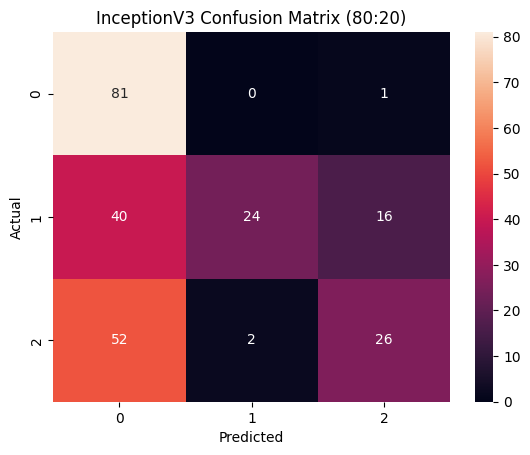

InceptionV3 model saved at: /content/drive/MyDrive/Stampede Prognosia/saved_models/inceptionv3_stampede_80_20.h5
Results saved successfully at: /content/drive/MyDrive/Stampede Prognosia/saved_models/inceptionv3_results_80_20.csv


In [ ]:
#MODEL 5: InceptionV3

from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

# DATA GENERATOR (80:20 split)
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest"
)

train_data = datagen.flow_from_directory(
    CAT_PATH,
    target_size=(299,299),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_data = datagen.flow_from_directory(
    CAT_PATH,
    target_size=(299,299),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# LOAD BASE MODEL
base = InceptionV3(weights="imagenet",
                   include_top=False,
                   input_shape=(299,299,3))

# Freeze all except last 30 layers
for layer in base.layers[:-30]:
    layer.trainable = False

# BUILD MODEL
model_inc = Sequential([
    base,
    GlobalAveragePooling2D(),
    Dense(256,activation="relu"),
    Dropout(0.5),
    Dense(3,activation="softmax")
])

model_inc.compile(
    optimizer=Adam(0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# TRAIN
history = model_inc.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)

# TRAINING ACCURACY
loss_train, acc_train = model_inc.evaluate(train_data)
print("\nInceptionV3 Training Accuracy:", round(acc_train*100,2), "%")

# VALIDATION ACCURACY
loss_val, acc_val = model_inc.evaluate(val_data)
print("InceptionV3 Validation Accuracy:", round(acc_val*100,2), "%")

# PREDICTIONS
y_true = val_data.classes
y_pred_probs = model_inc.predict(val_data)
y_pred = np.argmax(y_pred_probs, axis=1)

# METRICS
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')
kappa = cohen_kappa_score(y_true, y_pred)

print("Accuracy:", round(accuracy*100,2), "%")
print("Precision:", round(precision,3))
print("Recall:", round(recall,3))
print("F1-Score:", round(f1,3))
print("Kappa:", round(kappa,3))

# CONFUSION MATRIX
cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("InceptionV3 Confusion Matrix (80:20)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# SAVE MODEL PERMANENTLY
MODEL_SAVE_PATH = "/content/drive/MyDrive/Stampede Prognosia/saved_models"
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

inc_path = os.path.join(MODEL_SAVE_PATH, "inceptionv3_stampede_80_20.h5")
model_inc.save(inc_path)

print("InceptionV3 model saved at:", inc_path)

# SAVE RESULTS CSV
results = {
    "Model": "InceptionV3 (80:20)",
    "Train Accuracy (%)": round(acc_train*100,2),
    "Validation Accuracy (%)": round(accuracy*100,2),
    "Precision": round(precision,3),
    "Recall": round(recall,3),
    "F1-Score": round(f1,3),
    "Kappa": round(kappa,3)
}

df = pd.DataFrame([results])
csv_path = os.path.join(MODEL_SAVE_PATH, "inceptionv3_results_80_20.csv")
df.to_csv(csv_path, index=False)

print("Results saved successfully at:", csv_path)

In [ ]:
#MODEL 6: VGG16

from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam

base = VGG16(weights="imagenet",
             include_top=False,
             input_shape=(224,224,3))

for layer in base.layers[:-4]:
    layer.trainable = False

model_vgg = Sequential([
    base,
    GlobalAveragePooling2D(),
    Dense(256,activation="relu"),
    Dropout(0.5),
    Dense(3,activation="softmax")
])

model_vgg.compile(
    optimizer=Adam(0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model_vgg.fit(train_data,
                        validation_data=val_data,
                        epochs=20)

loss, acc = model_vgg.evaluate(val_data)
print("\nVGG16 Validation Accuracy:", round(acc*100,2), "%")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 875s 28s/step - accuracy: 0.4370 - loss: 1.0328 - val_accuracy: 0.5165 - val_loss: 1.1269
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 823s 27s/step - accuracy: 0.6480 - loss: 0.6894 - val_accuracy: 0.5372 - val_loss: 1.1778
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 854s 26s/step - accuracy: 0.7443 - loss: 0.5935 - val_accuracy: 0.6446 - val_loss: 0.9743
Epoch 4/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 822s 27s/step - accuracy: 0.7599 - loss: 0.5563 - val_accuracy: 0.6157 - val_loss: 0.9154
Epoch 5/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 813s 26s/step - accuracy: 0.7348 - loss: 0.6399 - val_accuracy: 0.6157 - val_loss: 0.9260
Epoch 6/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 817s 26s/step - accuracy: 0.7963 - loss: 0.4696 - val_accuracy: 0.6364 - val_loss: 0.8914
Epoch 7/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 823s 27s/step - accuracy: 0.7776 - loss: 0.4757 - val_accuracy: 0.6942 - val_loss: 0.7326
Epoch 8/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 858s 27s/step - accuracy: 0.8233 - loss: 0.4290 - val_accuracy: 0.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd

def evaluate_model_simple(model, model_name):

    y_true = val_data.classes
    y_pred_probs = model.predict(val_data)
    y_pred = np.argmax(y_pred_probs, axis=1)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro')
    rec = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')

    return [model_name,
            round(acc*100,2),
            round(prec,3),
            round(rec,3),
            round(f1,3)]

In [ ]:
results = []


results.append(evaluate_model_simple(model_vgg, "VGG16"))


df = pd.DataFrame(results,
                  columns=["Model", "Accuracy (%)", "Precision", "Recall", "F1-Score"])

df

8/8 ━━━━━━━━━━━━━━━━━━━━ 142s 17s/step


,Model,Accuracy (%),Precision,Recall,F1-Score
0,VGG16,73.55,0.759,0.734,0.724


To save the `model_vgg` (your trained VGG16 model), you can use the `save()` method. This will save the entire model (architecture, weights, and optimizer state) to a specified path.

In [ ]:
import os

# Define the directory to save the model
MODEL_SAVE_PATH = "/content/drive/MyDrive/Stampede Prognosia/saved_models"
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

# Save the VGG16 model
vgg16_model_path = os.path.join(MODEL_SAVE_PATH, "vgg16_crowd_counting_model.h5")
model_vgg.save(vgg16_model_path)

print(f"VGG16 model saved successfully at: {vgg16_model_path}")

VGG16 model saved successfully at: /content/drive/MyDrive/Stampede Prognosia/saved_models/vgg16_crowd_counting_model.h5


You can load the saved model back into memory later using `tf.keras.models.load_model`:

In [ ]:
from tensorflow.keras.models import load_model

# Load the saved VGG16 model
loaded_vgg16_model = load_model(vgg16_model_path)

print("VGG16 model loaded successfully!")
loaded_vgg16_model.summary()

VGG16 model loaded successfully!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,789 (56.64 MB)

 Trainable params: 7,211,523 (27.51 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

 Optimizer params: 2 (12.00 B)

In [ ]:
from tensorflow.keras.models import load_model

model_vgg = load_model("/content/drive/MyDrive/Stampede Prognosia/saved_models/vgg16_crowd_counting_model.h5")

In [ ]:
loss_train, acc_train = model_vgg.evaluate(train_data)
print("Training Accuracy:", round(acc_train*100,2), "%")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


31/31 ━━━━━━━━━━━━━━━━━━━━ 654s 20s/step - accuracy: 0.8768 - loss: 0.2800
Training Accuracy: 87.26 %


In [ ]:
from sklearn.metrics import cohen_kappa_score
import numpy as np

# True labels
y_true = val_data.classes

# Predicted probabilities
y_pred_probs = model_vgg.predict(val_data)

# Convert probabilities to class index
y_pred = np.argmax(y_pred_probs, axis=1)

# Calculate Kappa
kappa = cohen_kappa_score(y_true, y_pred)

print("Cohen's Kappa Score:", round(kappa, 3))

8/8 ━━━━━━━━━━━━━━━━━━━━ 158s 19s/step
Cohen's Kappa Score: 0.553


8/8 ━━━━━━━━━━━━━━━━━━━━ 157s 19s/step


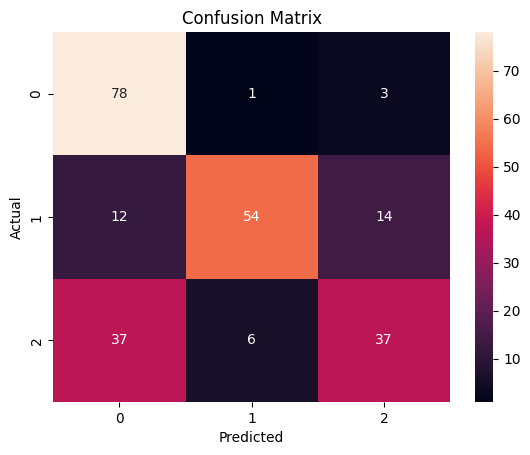

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

y_true = val_data.classes
y_pred = np.argmax(model_vgg.predict(val_data), axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=val_data.class_indices.keys()))

              precision    recall  f1-score   support

        high       0.61      0.95      0.75        82
         low       0.89      0.68      0.77        80
      medium       0.69      0.46      0.55        80

    accuracy                           0.70       242
   macro avg       0.73      0.70      0.69       242
weighted avg       0.73      0.70      0.69       242



In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

y_true_bin = label_binarize(y_true, classes=[0,1,2])
y_pred_probs = model_vgg.predict(val_data)

roc_auc = roc_auc_score(y_true_bin, y_pred_probs, average="macro")
print("ROC-AUC Score:", round(roc_auc,3))

8/8 ━━━━━━━━━━━━━━━━━━━━ 158s 19s/step
ROC-AUC Score: 0.905


Found 973 images belonging to 3 classes.
Found 242 images belonging to 3 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 98s 3s/step - accuracy: 0.4432 - loss: 1.1173 - val_accuracy: 0.4298 - val_loss: 1.7569
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 81s 3s/step - accuracy: 0.6489 - loss: 0.7551 - val_accuracy: 0.4256 - val_loss: 1.9791
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 84s 3s/step - accuracy: 0.6584 - loss: 0.6751 - val_accuracy: 0.4752 - val_loss: 1.7746
Epoch 4/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 83s 3s/step - accuracy: 0.7196 - loss: 0.6063 - val_accuracy: 0.4752 - val_loss: 1.6935
Epoch 5/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.7281 - loss: 0.6091 - val_accuracy: 0.4711 - val_loss: 1.9055
Epoch 6/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 89s 3s/step - accuracy: 0.7783 - loss: 0.5143 - val_accuracy: 0.4711 - val_loss: 2.0758
Epoch 7/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.7738 - loss: 0.5234 - val_accuracy: 0.4545 - val_loss: 2.0005
Epoch 8/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 90s 3s/step - accuracy: 0.8169 - loss: 0.4652 - val_accuracy: 0.4959 - val_loss:

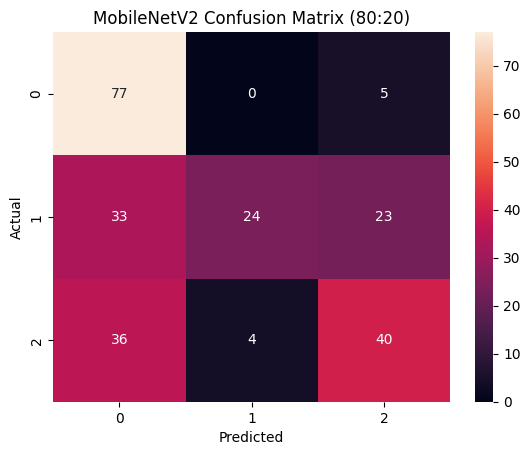

MobileNetV2 model saved at: /content/drive/MyDrive/Stampede Prognosia/saved_models/mobilenetv2_stampede_80_20.h5


In [ ]:
#MODEL 7: MobileNetV2

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd


train_data = datagen.flow_from_directory(
    CAT_PATH,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_data = datagen.flow_from_directory(
    CAT_PATH,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# ------------------- LOAD BASE MODEL -------------------
base = MobileNetV2(weights="imagenet",
                   include_top=False,
                   input_shape=(224,224,3))

# Freeze all except last 20 layers
for layer in base.layers[:-20]:
    layer.trainable = False

# ------------------- BUILD MODEL -------------------
model_mobilenet = Sequential([
    base,
    GlobalAveragePooling2D(),
    Dense(256, activation="relu"),
    Dropout(0.5),
    Dense(3, activation="softmax")
])

model_mobilenet.compile(
    optimizer=Adam(0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ------------------- TRAIN -------------------
history = model_mobilenet.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)

# ------------------- TRAIN ACCURACY -------------------
loss_train, acc_train = model_mobilenet.evaluate(train_data)
print("\nMobileNetV2 Training Accuracy:", round(acc_train*100,2), "%")

# ------------------- VALIDATION ACCURACY -------------------
loss_val, acc_val = model_mobilenet.evaluate(val_data)
print("MobileNetV2 Validation Accuracy:", round(acc_val*100,2), "%")

# ------------------- PREDICTIONS -------------------
y_true = val_data.classes
y_pred_probs = model_mobilenet.predict(val_data)
y_pred = np.argmax(y_pred_probs, axis=1)

# ------------------- METRICS -------------------
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')
kappa = cohen_kappa_score(y_true, y_pred)

print("Accuracy:", round(accuracy*100,2), "%")
print("Precision:", round(precision,3))
print("Recall:", round(recall,3))
print("F1-Score:", round(f1,3))
print("Kappa:", round(kappa,3))

# ------------------- CONFUSION MATRIX -------------------
cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("MobileNetV2 Confusion Matrix (80:20)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ------------------- SAVE MODEL -------------------
MODEL_SAVE_PATH = "/content/drive/MyDrive/Stampede Prognosia/saved_models"
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

mobile_path = os.path.join(MODEL_SAVE_PATH, "mobilenetv2_stampede_80_20.h5")
model_mobilenet.save(mobile_path)

print("MobileNetV2 model saved at:", mobile_path)



70:30 Split

In [ ]:
import tensorflow as tf
import numpy as np
import random

SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

In [ ]:
#Common Data Generator

from tensorflow.keras.preprocessing.image import ImageDataGenerator

CAT_PATH = "/content/drive/MyDrive/Stampede Prognosia/categorized_images"

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.3,
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest"
)

train_data = datagen.flow_from_directory(
    CAT_PATH,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=SEED
)

val_data = datagen.flow_from_directory(
    CAT_PATH,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=SEED
)

print("Training Samples:", train_data.samples)
print("Validation Samples:", val_data.samples)

Found 852 images belonging to 3 classes.
Found 363 images belonging to 3 classes.
Training Samples: 852
Validation Samples: 363


In [ ]:
#Class Weights

import numpy as np
from sklearn.utils.class_weight import compute_class_weight

y_classes = train_data.classes

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_classes),
    y=y_classes
)

class_weights = dict(enumerate(class_weights))
print(class_weights)


{0: np.float64(0.9826989619377162), 1: np.float64(1.01067615658363), 2: np.float64(1.0070921985815602)}


In [ ]:
#MODEL 1:  CNN

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

cnn_model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256,activation='relu'),
    Dropout(0.5),
    Dense(3,activation='softmax')
])

cnn_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = cnn_model.fit(train_data,
                        validation_data=val_data,
                        epochs=20)

loss, acc = cnn_model.evaluate(val_data)
print("\nCNN Validation Accuracy:", round(acc*100,2), "%")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 676s 25s/step - accuracy: 0.5163 - loss: 3.8926 - val_accuracy: 0.3306 - val_loss: 4.8840
Epoch 2/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 231s 9s/step - accuracy: 0.5974 - loss: 0.8427 - val_accuracy: 0.3306 - val_loss: 13.7281
Epoch 3/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 247s 9s/step - accuracy: 0.6396 - loss: 0.7762 - val_accuracy: 0.3306 - val_loss: 20.8764
Epoch 4/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 225s 8s/step - accuracy: 0.6009 - loss: 0.7795 - val_accuracy: 0.3306 - val_loss: 26.4097
Epoch 5/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 245s 8s/step - accuracy: 0.6468 - loss: 0.7235 - val_accuracy: 0.3306 - val_loss: 30.7871
Epoch 6/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 267s 8s/step - accuracy: 0.6599 - loss: 0.6970 - val_accuracy: 0.3306 - val_loss: 33.3476
Epoch 7/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 189s 7s/step - accuracy: 0.6778 - loss: 0.6726 - val_accuracy: 0.3306 - val_loss: 34.7524
Epoch 8/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 203s 7s/step - accuracy: 0.6659 - loss: 0.7198 - val_accuracy: 0.3

In [ ]:
loss, acc = cnn_model.evaluate(val_data)
print("Validation Accuracy:", round(acc*100,2), "%")

12/12 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.6944 - loss: 0.9927
Validation Accuracy: 59.78 %


In [ ]:

loss_train, acc_train = cnn_model.evaluate(train_data)
print("CNN Training Accuracy:", round(acc_train*100,2), "%")

27/27 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - accuracy: 0.5532 - loss: 1.1779
CNN Training Accuracy: 56.81 %


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score
import numpy as np

# True labels
y_true = val_data.classes

# Predictions
y_pred_probs = cnn_model.predict(val_data)
y_pred = np.argmax(y_pred_probs, axis=1)

# Metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')
kappa = cohen_kappa_score(y_true, y_pred)

print("Accuracy:", round(accuracy*100,2), "%")
print("Precision:", round(precision,3))
print("Recall:", round(recall,3))
print("F1-Score:", round(f1,3))
print("Kappa:", round(kappa,3))

12/12 ━━━━━━━━━━━━━━━━━━━━ 39s 3s/step
Accuracy: 60.06 %
Precision: 0.618
Recall: 0.6
F1-Score: 0.558
Kappa: 0.401


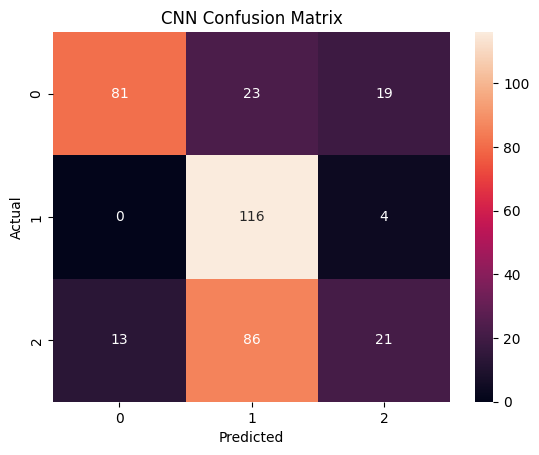

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
import os

MODEL_SAVE_PATH = "/content/drive/MyDrive/Stampede Prognosia/saved_models"
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

cnn_model_path = os.path.join(MODEL_SAVE_PATH, "cnn_stampede_model_70_30.h5")

cnn_model.save(cnn_model_path)

print("CNN model saved at:", cnn_model_path)

CNN model saved at: /content/drive/MyDrive/Stampede Prognosia/saved_models/cnn_stampede_model_70_30.h5


In [ ]:
import pandas as pd

results = {
    "Model": "CNN (70:30)",
    "Accuracy (%)": round(accuracy*100,2),
    "Precision": round(precision,3),
    "Recall": round(recall,3),
    "F1-Score": round(f1,3),
    "Kappa": round(kappa,3)
}

df = pd.DataFrame([results])
df.to_csv("cnn_results_70_30.csv", index=False)

print("Results saved successfully.")

Results saved successfully.


In [ ]:
#MODEL 2: RESNET50


from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

base = ResNet50(weights="imagenet",
                include_top=False,
                input_shape=(224,224,3))

for layer in base.layers[:-20]:
    layer.trainable = False

model_res = Sequential([
    base,
    GlobalAveragePooling2D(),
    Dense(256,activation="relu"),
    Dropout(0.5),
    Dense(3,activation="softmax")
])

model_res.compile(
    optimizer=Adam(0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model_res.fit(train_data,
                        validation_data=val_data,
                        epochs=20)

loss, acc = model_res.evaluate(val_data)
print("\nResNet50 Validation Accuracy:", round(acc*100,2), "%")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Epoch 1/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 412s 15s/step - accuracy: 0.4590 - loss: 1.0659 - val_accuracy: 0.3361 - val_loss: 1.1892
Epoch 2/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 320s 12s/step - accuracy: 0.6366 - loss: 0.7688 - val_accuracy: 0.4738 - val_loss: 1.2024
Epoch 3/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 323s 12s/step - accuracy: 0.6355 - loss: 0.7148 - val_accuracy: 0.4628 - val_loss: 1.2233
Epoch 4/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 326s 12s/step - accuracy: 0.6733 - loss: 0.7275 - val_accuracy: 0.4518 - val_loss: 1.1858
Epoch 5/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 313s 12s/step - accuracy: 0.7025 - loss: 0.6462 - val_accuracy: 0.4160 - val_loss: 1.2320
Epoch 6/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 326s 12s/step - accuracy: 0.6921 - loss: 0.6837 - val_accuracy: 0.4683 - val_loss: 1.0740
Epoch 7/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 322s 12s/step - accuracy: 0.6713 - loss: 0.6617 - val_accuracy: 0.5289 - val_loss: 0.9600
Epoch 8/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 391s 15s/step -

In [ ]:
loss_train, acc_train = model_res.evaluate(train_data)
print("ResNet50 Training Accuracy:", round(acc_train*100,2), "%")

27/27 ━━━━━━━━━━━━━━━━━━━━ 193s 7s/step - accuracy: 0.6569 - loss: 0.6711
ResNet50 Training Accuracy: 66.08 %


In [ ]:
loss_val, acc_val = model_res.evaluate(val_data)
print("Validation Accuracy:", round(acc_val*100,2), "%")

12/12 ━━━━━━━━━━━━━━━━━━━━ 87s 7s/step - accuracy: 0.7989 - loss: 0.6472
Validation Accuracy: 60.61 %


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score
import numpy as np

# True labels
y_true = val_data.classes

# Predictions
y_pred_probs = model_res.predict(val_data)
y_pred = np.argmax(y_pred_probs, axis=1)

# Metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')
kappa = cohen_kappa_score(y_true, y_pred)

print("Accuracy:", round(accuracy*100,2), "%")
print("Precision:", round(precision,3))
print("Recall:", round(recall,3))
print("F1-Score:", round(f1,3))
print("Kappa:", round(kappa,3))

12/12 ━━━━━━━━━━━━━━━━━━━━ 94s 7s/step
Accuracy: 63.91 %
Precision: 0.698
Recall: 0.636
F1-Score: 0.58
Kappa: 0.457


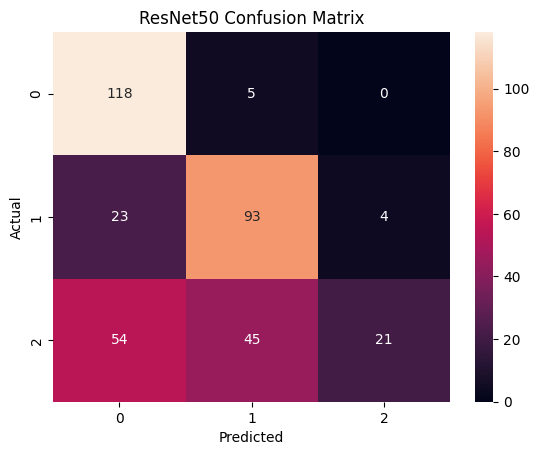

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("ResNet50 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=val_data.class_indices.keys()
))

              precision    recall  f1-score   support

        high       0.61      0.96      0.74       123
         low       0.65      0.78      0.71       120
      medium       0.84      0.17      0.29       120

    accuracy                           0.64       363
   macro avg       0.70      0.64      0.58       363
weighted avg       0.70      0.64      0.58       363



In [ ]:
import os

MODEL_SAVE_PATH = "/content/drive/MyDrive/Stampede Prognosia/saved_models"
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

resnet_path = os.path.join(MODEL_SAVE_PATH, "resnet50_stampede_70_30.h5")

model_res.save(resnet_path)

print("ResNet50 model saved at:", resnet_path)

ResNet50 model saved at: /content/drive/MyDrive/Stampede Prognosia/saved_models/resnet50_stampede_70_30.h5


In [ ]:
#MODEL 3: DENSENET121


from tensorflow.keras.applications import DenseNet121

base = DenseNet121(weights="imagenet",
                   include_top=False,
                   input_shape=(224,224,3))

for layer in base.layers[:-20]:
    layer.trainable = False

model_dense = Sequential([
    base,
    GlobalAveragePooling2D(),
    Dense(256,activation="relu"),
    Dropout(0.5),
    Dense(3,activation="softmax")
])

model_dense.compile(
    optimizer=Adam(0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model_dense.fit(train_data,
                          validation_data=val_data,
                          epochs=20)

loss, acc = model_dense.evaluate(val_data)
print("\nDenseNet121 Validation Accuracy:", round(acc*100,2), "%")

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 315s 11s/step - accuracy: 0.3871 - loss: 1.3239 - val_accuracy: 0.4986 - val_loss: 1.1021
Epoch 2/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 263s 10s/step - accuracy: 0.5062 - loss: 1.0246 - val_accuracy: 0.5289 - val_loss: 0.9904
Epoch 3/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 272s 10s/step - accuracy: 0.5707 - loss: 0.8404 - val_accuracy: 0.5399 - val_loss: 1.0382
Epoch 4/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 260s 10s/step - accuracy: 0.6248 - loss: 0.7763 - val_accuracy: 0.5455 - val_loss: 1.0162
Epoch 5/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 275s 10s/step - accuracy: 0.6201 - loss: 0.7788 - val_accuracy: 0.5565 - val_loss: 1.0221
Epoch 6/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 248s 9s/step - accuracy: 0.6527 - loss: 0.7592 - val_accuracy: 0.5592 - val_loss: 1.1064
Epoch 7/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 247s 9s/step - accuracy: 0.6657 - loss: 0.7010 - val_accuracy: 0.5427 - val_loss: 1.0890
Epoch 8/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 247s 9s/step - accuracy: 0.6550 - loss: 0.6922 - val_accuracy: 0.567

In [ ]:
loss_train, acc_train = model_dense.evaluate(train_data)
print("DenseNet121 Training Accuracy:", round(acc_train*100,2), "%")

27/27 ━━━━━━━━━━━━━━━━━━━━ 172s 6s/step - accuracy: 0.8454 - loss: 0.3995
DenseNet121 Training Accuracy: 83.69 %


In [ ]:
loss_val, acc_val = model_dense.evaluate(val_data)
print("DenseNet121 Validation Accuracy:", round(acc_val*100,2), "%")

12/12 ━━━━━━━━━━━━━━━━━━━━ 78s 6s/step - accuracy: 0.7819 - loss: 0.6116
DenseNet121 Validation Accuracy: 63.91 %


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score
import numpy as np

# True labels
y_true = val_data.classes

# Predictions
y_pred_probs = model_dense.predict(val_data)
y_pred = np.argmax(y_pred_probs, axis=1)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')
kappa = cohen_kappa_score(y_true, y_pred)

print("Accuracy:", round(accuracy*100,2), "%")
print("Precision:", round(precision,3))
print("Recall:", round(recall,3))
print("F1-Score:", round(f1,3))
print("Kappa:", round(kappa,3))

12/12 ━━━━━━━━━━━━━━━━━━━━ 94s 7s/step
Accuracy: 65.29 %
Precision: 0.719
Recall: 0.65
F1-Score: 0.638
Kappa: 0.478


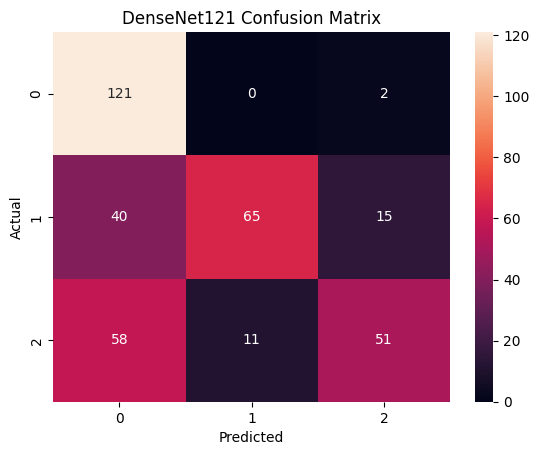

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("DenseNet121 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=val_data.class_indices.keys()
))

              precision    recall  f1-score   support

        high       0.55      0.98      0.71       123
         low       0.86      0.54      0.66       120
      medium       0.75      0.42      0.54       120

    accuracy                           0.65       363
   macro avg       0.72      0.65      0.64       363
weighted avg       0.72      0.65      0.64       363



In [ ]:
import os

MODEL_SAVE_PATH = "/content/drive/MyDrive/Stampede Prognosia/saved_models"
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

dense_path = os.path.join(MODEL_SAVE_PATH, "densenet121_stampede_70_30.h5")

model_dense.save(dense_path)

print("DenseNet121 model saved at:", dense_path)

DenseNet121 model saved at: /content/drive/MyDrive/Stampede Prognosia/saved_models/densenet121_stampede_70_30.h5


In [ ]:
#MODEL 4: EFFICIENTNETB0

from tensorflow.keras.applications import EfficientNetB0

base = EfficientNetB0(weights="imagenet",
                      include_top=False,
                      input_shape=(224,224,3))

for layer in base.layers[:-20]:
    layer.trainable = False

model_eff = Sequential([
    base,
    GlobalAveragePooling2D(),
    Dense(256,activation="relu"),
    Dropout(0.5),
    Dense(3,activation="softmax")
])

model_eff.compile(
    optimizer=Adam(0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model_eff.fit(train_data,
                        validation_data=val_data,
                        epochs=20)

loss, acc = model_eff.evaluate(val_data)
print("\nEfficientNetB0 Validation Accuracy:", round(acc*100,2), "%")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 150s 5s/step - accuracy: 0.3468 - loss: 1.1153 - val_accuracy: 0.4132 - val_loss: 1.0991
Epoch 2/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 181s 7s/step - accuracy: 0.3819 - loss: 1.0993 - val_accuracy: 0.3388 - val_loss: 1.1058
Epoch 3/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 124s 5s/step - accuracy: 0.4063 - loss: 1.0929 - val_accuracy: 0.4986 - val_loss: 1.1018
Epoch 4/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 123s 5s/step - accuracy: 0.4455 - loss: 1.0479 - val_accuracy: 0.3388 - val_loss: 1.0987
Epoch 5/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 124s 5s/step - accuracy: 0.4437 - loss: 1.0324 - val_accuracy: 0.3388 - val_loss: 1.1001
Epoch 6/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 126s 5s/step - accuracy: 0.4733 - loss: 1.0178 - val_accuracy: 0.3388 - val_loss: 1.1147
Epoch 7/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 127s 5s/step - accuracy: 0.4994 - loss: 1.0069 - val_accuracy: 0.3388 - val_loss: 1.1119
Epoch 8/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 126s 5s/step - accuracy: 0.4990 - loss: 0.9892 - val_accuracy: 0.3388 - v

In [ ]:
loss_train, acc_train = model_eff.evaluate(train_data)
print("EfficientNetB0 Training Accuracy:", round(acc_train*100,2), "%")

27/27 ━━━━━━━━━━━━━━━━━━━━ 108s 4s/step - accuracy: 0.4584 - loss: 0.9418
EfficientNetB0 Training Accuracy: 45.77 %


In [ ]:
loss_val, acc_val = model_eff.evaluate(val_data)
print("EfficientNetB0 Validation Accuracy:", round(acc_val*100,2), "%")

12/12 ━━━━━━━━━━━━━━━━━━━━ 48s 4s/step - accuracy: 0.6772 - loss: 0.6960
EfficientNetB0 Validation Accuracy: 45.73 %


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score
import numpy as np

y_true = val_data.classes
y_pred_probs = model_eff.predict(val_data)
y_pred = np.argmax(y_pred_probs, axis=1)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')
kappa = cohen_kappa_score(y_true, y_pred)

print("Accuracy:", round(accuracy*100,2), "%")
print("Precision:", round(precision,3))
print("Recall:", round(recall,3))
print("F1-Score:", round(f1,3))
print("Kappa:", round(kappa,3))

12/12 ━━━━━━━━━━━━━━━━━━━━ 52s 3s/step
Accuracy: 44.63 %
Precision: 0.575
Recall: 0.442
F1-Score: 0.383
Kappa: 0.165


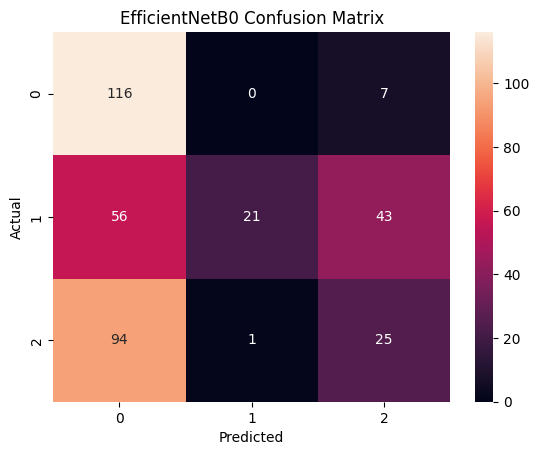

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("EfficientNetB0 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
import os

MODEL_SAVE_PATH = "/content/drive/MyDrive/Stampede Prognosia/saved_models"
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

eff_path = os.path.join(MODEL_SAVE_PATH, "efficientnetb0_stampede_70_30.h5")

model_eff.save(eff_path)

print("EfficientNetB0 model saved at:", eff_path)

EfficientNetB0 model saved at: /content/drive/MyDrive/Stampede Prognosia/saved_models/efficientnetb0_stampede_70_30.h5


In [ ]:
#MODEL 5: INCEPTIONV3

from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Redefine datagen for 70:30 split with 299x299 size
datagen_299 = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.3
)

train_data_299 = datagen_299.flow_from_directory(
    CAT_PATH,
    target_size=(299,299),   # Required for InceptionV3
    batch_size=32,
    class_mode='categorical',
    subset='training',
    seed=42
)

val_data_299 = datagen_299.flow_from_directory(
    CAT_PATH,
    target_size=(299,299),   # Required for InceptionV3
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

base = InceptionV3(weights="imagenet",
                   include_top=False,
                   input_shape=(299,299,3))

for layer in base.layers[:-30]:
    layer.trainable = False

model_inc = Sequential([
    base,
    GlobalAveragePooling2D(),
    Dense(256,activation="relu"),
    Dropout(0.5),
    Dense(3,activation="softmax")
])

model_inc.compile(
    optimizer=Adam(0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model_inc.fit(train_data_299,
                        validation_data=val_data_299,
                        epochs=20)

# Overall Training Accuracy
loss_train, acc_train = model_inc.evaluate(train_data_299)
print("\nInceptionV3 Training Accuracy:", round(acc_train*100,2), "%")

# Validation Accuracy
loss_val, acc_val = model_inc.evaluate(val_data_299)
print("InceptionV3 Validation Accuracy:", round(acc_val*100,2), "%")

Found 852 images belonging to 3 classes.
Found 363 images belonging to 3 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 395s 14s/step - accuracy: 0.5231 - loss: 0.9778 - val_accuracy: 0.5510 - val_loss: 0.9247
Epoch 2/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 363s 14s/step - accuracy: 0.7709 - loss: 0.5599 - val_accuracy: 0.5785 - val_loss: 0.9843
Epoch 3/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 358s 13s/step - accuracy: 0.8411 - loss: 0.4283 - val_accuracy: 0.6116 - val_loss: 1.0237
Epoch 4/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 356s 13s/step - accuracy: 0.8948 - loss: 0.3301 - val_accuracy: 0.6281 - val_loss: 0.9481
Epoch 5/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 354s 13s/step - accuracy: 0.9447 - loss: 0.2269 - val_accuracy: 0.6474 - val_loss: 0.9194
Epoch 6/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 349s 13s/step - accuracy: 0.9632 - loss: 0.1603 - val_accuracy: 0.6446 - val_loss: 1.0221
Epoch 7/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 364s 14s/step - accuracy: 0.9800 - loss: 0.1121 - val_accuracy: 0.6253 - val_loss: 1.1652
Epoch 8/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 356s 13s/step - accuracy: 0.9944 - loss: 0.0551 - val_accuracy: 0.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score
import numpy as np

y_true = val_data_299.classes
y_pred_probs = model_inc.predict(val_data_299)
y_pred = np.argmax(y_pred_probs, axis=1)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')
kappa = cohen_kappa_score(y_true, y_pred)

print("Accuracy:", round(accuracy*100,2), "%")
print("Precision:", round(precision,3))
print("Recall:", round(recall,3))
print("F1-Score:", round(f1,3))
print("Kappa:", round(kappa,3))

12/12 ━━━━━━━━━━━━━━━━━━━━ 124s 9s/step
Accuracy: 63.09 %
Precision: 0.694
Recall: 0.628
F1-Score: 0.611
Kappa: 0.444


12/12 ━━━━━━━━━━━━━━━━━━━━ 119s 10s/step


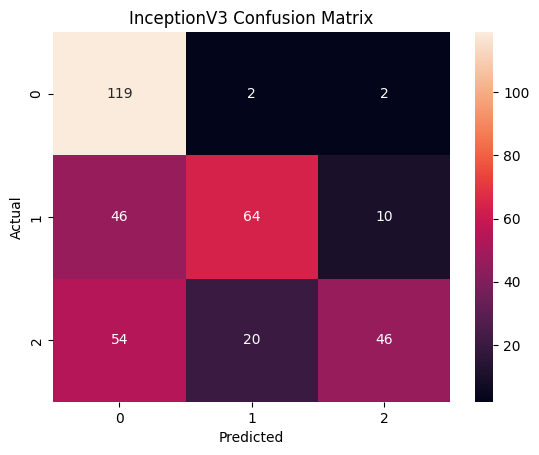

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# True labels
y_true = val_data_299.classes

# Predictions
y_pred_probs = model_inc.predict(val_data_299)
y_pred = np.argmax(y_pred_probs, axis=1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("InceptionV3 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=val_data_299.class_indices.keys()
))

              precision    recall  f1-score   support

        high       0.54      0.97      0.70       123
         low       0.74      0.53      0.62       120
      medium       0.79      0.38      0.52       120

    accuracy                           0.63       363
   macro avg       0.69      0.63      0.61       363
weighted avg       0.69      0.63      0.61       363



In [ ]:
import os

MODEL_SAVE_PATH = "/content/drive/MyDrive/Stampede Prognosia/saved_models"
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

inc_path = os.path.join(MODEL_SAVE_PATH, "inceptionv3_stampede_70_30.h5")

model_inc.save(inc_path)

print("InceptionV3 model saved at:", inc_path)

InceptionV3 model saved at: /content/drive/MyDrive/Stampede Prognosia/saved_models/inceptionv3_stampede_70_30.h5


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 831s 31s/step - accuracy: 0.4769 - loss: 1.0066 - val_accuracy: 0.6198 - val_loss: 0.9144
Epoch 2/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 860s 32s/step - accuracy: 0.6376 - loss: 0.7263 - val_accuracy: 0.6198 - val_loss: 0.9129
Epoch 3/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 852s 32s/step - accuracy: 0.7011 - loss: 0.6000 - val_accuracy: 0.6804 - val_loss: 0.8425
Epoch 4/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 793s 30s/step - accuracy: 0.7224 - loss: 0.5957 - val_accuracy: 0.6777 - val_loss: 0.7503
Epoch 5/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 850s 32s/step - accuracy: 0.7464 - loss: 0.5716 - val_accuracy: 0.6860 - val_loss: 0.8978
Epoch 6/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 793s 30s/step - accuracy: 0.7806 - loss: 0.5069 - val_accuracy: 0.7218 - val_loss: 0.7079
Epoch 7/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 793s 30s/step - accuracy: 0.7206 - loss: 0.5771 - val_accuracy: 0.7300 - val_loss: 0.6547
Epoch 8/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 793s 30s/step - accuracy: 0.7898 - loss: 0.5087 - val_accuracy: 0.

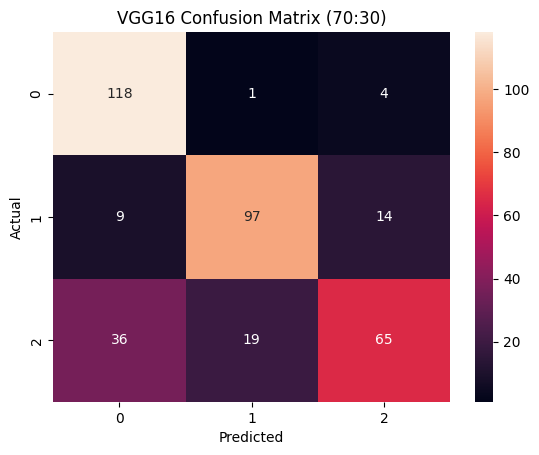

VGG16 model saved at: /content/drive/MyDrive/Stampede Prognosia/saved_models/vgg16_stampede_70_30.h5
Results saved successfully at: /content/drive/MyDrive/Stampede Prognosia/saved_models/vgg16_results_70_30.csv


In [ ]:
#MODEL 6: VGG16

from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

# LOAD BASE MODEL
base = VGG16(weights="imagenet",
             include_top=False,
             input_shape=(224,224,3))

# Freeze all except last 4 layers
for layer in base.layers[:-4]:
    layer.trainable = False

# BUILD MODEL
model_vgg = Sequential([
    base,
    GlobalAveragePooling2D(),
    Dense(256,activation="relu"),
    Dropout(0.5),
    Dense(3,activation="softmax")
])

model_vgg.compile(
    optimizer=Adam(0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# TRAIN (70:30 assumed already split)
history = model_vgg.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)

# TRAINING ACCURACY
loss_train, acc_train = model_vgg.evaluate(train_data)
print("\nVGG16 Training Accuracy:", round(acc_train*100,2), "%")

# VALIDATION ACCURACY
loss_val, acc_val = model_vgg.evaluate(val_data)
print("VGG16 Validation Accuracy:", round(acc_val*100,2), "%")

# PREDICTIONS
y_true = val_data.classes
y_pred_probs = model_vgg.predict(val_data)
y_pred = np.argmax(y_pred_probs, axis=1)

# METRICS
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')
kappa = cohen_kappa_score(y_true, y_pred)

print("Accuracy:", round(accuracy*100,2), "%")
print("Precision:", round(precision,3))
print("Recall:", round(recall,3))
print("F1-Score:", round(f1,3))
print("Kappa:", round(kappa,3))

# CONFUSION MATRIX
cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("VGG16 Confusion Matrix (70:30)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# SAVE MODEL PERMANENTLY
MODEL_SAVE_PATH = "/content/drive/MyDrive/Stampede Prognosia/saved_models"
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

vgg_path = os.path.join(MODEL_SAVE_PATH, "vgg16_stampede_70_30.h5")
model_vgg.save(vgg_path)

print("VGG16 model saved at:", vgg_path)

# SAVE RESULTS CSV
results = {
    "Model": "VGG16 (70:30)",
    "Train Accuracy (%)": round(acc_train*100,2),
    "Validation Accuracy (%)": round(accuracy*100,2),
    "Precision": round(precision,3),
    "Recall": round(recall,3),
    "F1-Score": round(f1,3),
    "Kappa": round(kappa,3)
}

df = pd.DataFrame([results])
csv_path = os.path.join(MODEL_SAVE_PATH, "vgg16_results_70_30.csv")
df.to_csv(csv_path, index=False)

print("Results saved successfully at:", csv_path)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 124s 4s/step - accuracy: 0.4703 - loss: 1.1073 - val_accuracy: 0.5179 - val_loss: 1.1713
Epoch 2/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 97s 4s/step - accuracy: 0.6287 - loss: 0.7844 - val_accuracy: 0.5344 - val_loss: 1.2201
Epoch 3/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 97s 4s/step - accuracy: 0.7131 - loss: 0.6597 - val_accuracy: 0.5344 - val_loss: 1.4355
Epoch 4/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 94s 4s/step - accuracy: 0.7125 - loss: 0.5902 - val_accuracy: 0.5262 - val_loss: 1.6176
Epoch 5/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 93s 3s/step - accuracy: 0.7626 - loss: 0.5830 - val_accuracy: 0.5207 - val_loss: 1.6029
Epoch 6/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 96s 4s/step - accuracy: 0.7455 - loss: 0.5783 - val_accuracy: 0.5399 - val_loss: 1.5693
Epoch 7/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 95s 4s/step - accuracy: 0.7592 - loss: 0.5376 - val_accuracy: 0.5399 - val_loss: 1.8575
Epoch 8/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 96s 4s/step - accuracy: 0.7309

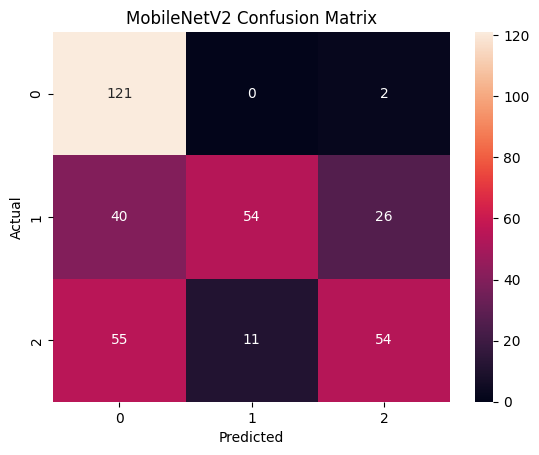

MobileNetV2 model saved at: /content/drive/MyDrive/Stampede Prognosia/saved_models/mobilenetv2_stampede_70_30.h5
Results saved successfully.


In [ ]:
#MODEL 7: MOBILENETV2

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

base = MobileNetV2(weights="imagenet",
                   include_top=False,
                   input_shape=(224,224,3))

for layer in base.layers[:-20]:
    layer.trainable = False

model_mobilenet = Sequential([
    base,
    GlobalAveragePooling2D(),
    Dense(256, activation="relu"),
    Dropout(0.5),
    Dense(3, activation="softmax")
])

model_mobilenet.compile(
    optimizer=Adam(0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model_mobilenet.fit(train_data,
                              validation_data=val_data,
                              epochs=20)

# Overall Training Accuracy
loss_train, acc_train = model_mobilenet.evaluate(train_data)
print("\nMobileNetV2 Training Accuracy:", round(acc_train*100,2), "%")

# Validation Accuracy
loss_val, acc_val = model_mobilenet.evaluate(val_data)
print("MobileNetV2 Validation Accuracy:", round(acc_val*100,2), "%")

# Predictions for metrics
y_true = val_data.classes
y_pred_probs = model_mobilenet.predict(val_data)
y_pred = np.argmax(y_pred_probs, axis=1)

# Evaluation Metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')
kappa = cohen_kappa_score(y_true, y_pred)

print("Accuracy:", round(accuracy*100,2), "%")
print("Precision:", round(precision,3))
print("Recall:", round(recall,3))
print("F1-Score:", round(f1,3))
print("Kappa:", round(kappa,3))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("MobileNetV2 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Save Model
MODEL_SAVE_PATH = "/content/drive/MyDrive/Stampede Prognosia/saved_models"
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

mobile_path = os.path.join(MODEL_SAVE_PATH, "mobilenetv2_stampede_70_30.h5")
model_mobilenet.save(mobile_path)

print("MobileNetV2 model saved at:", mobile_path)

# Save Results CSV
results = {
    "Model": "MobileNetV2 (70:30)",
    "Train Accuracy (%)": round(acc_train*100,2),
    "Validation Accuracy (%)": round(accuracy*100,2),
    "Precision": round(precision,3),
    "Recall": round(recall,3),
    "F1-Score": round(f1,3),
    "Kappa": round(kappa,3)
}

df = pd.DataFrame([results])
df.to_csv("mobilenetv2_results_70_30.csv", index=False)

print("Results saved successfully.")

60:40 Split

In [ ]:
import tensorflow as tf
import numpy as np
import random

SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

In [ ]:
#Common Data Generator

from tensorflow.keras.preprocessing.image import ImageDataGenerator

CAT_PATH = "/content/drive/MyDrive/Stampede Prognosia/categorized_images"

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.4,
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest"
)

train_data = datagen.flow_from_directory(
    CAT_PATH,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=SEED
)

val_data = datagen.flow_from_directory(
    CAT_PATH,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=SEED
)

print("Training Samples:", train_data.samples)
print("Validation Samples:", val_data.samples)

Found 731 images belonging to 3 classes.
Found 484 images belonging to 3 classes.
Training Samples: 731
Validation Samples: 484


In [ ]:
#Class Weights

import numpy as np
from sklearn.utils.class_weight import compute_class_weight

y_classes = train_data.classes

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_classes),
    y=y_classes
)

class_weights = dict(enumerate(class_weights))
print(class_weights)


{0: np.float64(0.9825268817204301), 1: np.float64(1.0110650069156293), 2: np.float64(1.0068870523415978)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 185s 8s/step - accuracy: 0.4581 - loss: 5.8574 - val_accuracy: 0.3306 - val_loss: 6.4970
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 174s 8s/step - accuracy: 0.5811 - loss: 0.9210 - val_accuracy: 0.3306 - val_loss: 12.6140
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 173s 8s/step - accuracy: 0.6277 - loss: 0.7773 - val_accuracy: 0.3306 - val_loss: 17.2898
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 182s 8s/step - accuracy: 0.6192 - loss: 0.7727 - val_accuracy: 0.3306 - val_loss: 20.8854
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 174s 8s/step - accuracy: 0.5785 - loss: 0.7464 - val_accuracy: 0.3306 - val_loss: 24.3791
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 175s 8s/step - accuracy: 0.5923 - loss: 0.7370 - val_accuracy: 0.3409 - val_loss: 26.8401
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 174s 8s/step - accuracy: 0.6290 - loss: 0.7639 - val_accuracy: 0.3368 - val_loss: 28.6604
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 188s 8s/step - accuracy: 0.6448 - loss: 0.7222 - val_accuracy: 0.33

16/16 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step
Accuracy: 38.43 %
Precision: 0.489
Recall: 0.386
F1-Score: 0.267
Kappa: 0.08


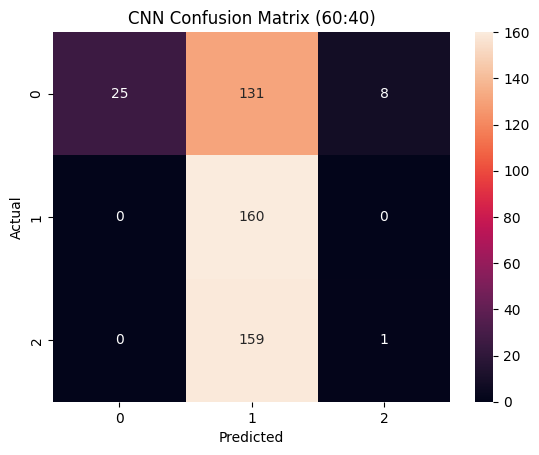

CNN model saved at: /content/drive/MyDrive/Stampede Prognosia/saved_models/cnn_stampede_60_40.h5


In [ ]:
#MODEL 1: CNN

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

# ------------------- CNN MODEL -------------------
cnn_model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256,activation='relu'),
    Dropout(0.5),
    Dense(3,activation='softmax')
])

cnn_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ------------------- TRAIN -------------------
history = cnn_model.fit(
    train_data,          # Already 60%
    validation_data=val_data,  # Already 40%
    epochs=20
)

# ------------------- TRAIN ACCURACY -------------------
loss_train, acc_train = cnn_model.evaluate(train_data)
print("\nCNN Training Accuracy:", round(acc_train*100,2), "%")

# ------------------- VALIDATION ACCURACY -------------------
loss_val, acc_val = cnn_model.evaluate(val_data)
print("CNN Validation Accuracy:", round(acc_val*100,2), "%")

# ------------------- PREDICTIONS -------------------
y_true = val_data.classes
y_pred_probs = cnn_model.predict(val_data)
y_pred = np.argmax(y_pred_probs, axis=1)

# ------------------- METRICS -------------------
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')
kappa = cohen_kappa_score(y_true, y_pred)

print("Accuracy:", round(accuracy*100,2), "%")
print("Precision:", round(precision,3))
print("Recall:", round(recall,3))
print("F1-Score:", round(f1,3))
print("Kappa:", round(kappa,3))

# ------------------- CONFUSION MATRIX -------------------
cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("CNN Confusion Matrix (60:40)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ------------------- SAVE MODEL -------------------
MODEL_SAVE_PATH = "/content/drive/MyDrive/Stampede Prognosia/saved_models"
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

cnn_path = os.path.join(MODEL_SAVE_PATH, "cnn_stampede_60_40.h5")
cnn_model.save(cnn_path)

print("CNN model saved at:", cnn_path)



94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 311s 13s/step - accuracy: 0.4450 - loss: 1.0662 - val_accuracy: 0.3388 - val_loss: 1.0994
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 285s 13s/step - accuracy: 0.5567 - loss: 0.8525 - val_accuracy: 0.3388 - val_loss: 1.1057
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 288s 13s/step - accuracy: 0.6018 - loss: 0.8071 - val_accuracy: 0.3388 - val_loss: 1.0996
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 288s 13s/step - accuracy: 0.6331 - loss: 0.7895 - val_accuracy: 0.3636 - val_loss: 1.0892
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 287s 13s/step - accuracy: 0.6310 - loss: 0.7435 - val_accuracy: 0.5227 - val_loss: 1.0509
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 332s 15s/step - accuracy: 0.6662 - loss: 0.7014 - val_accuracy: 0.4649 - val_loss: 1.0044
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 288s 13s/step - accuracy: 0.6907 - loss: 0.6684 - val_accuracy: 0.5579 - val_loss: 0.9503
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 289s 13s/step -

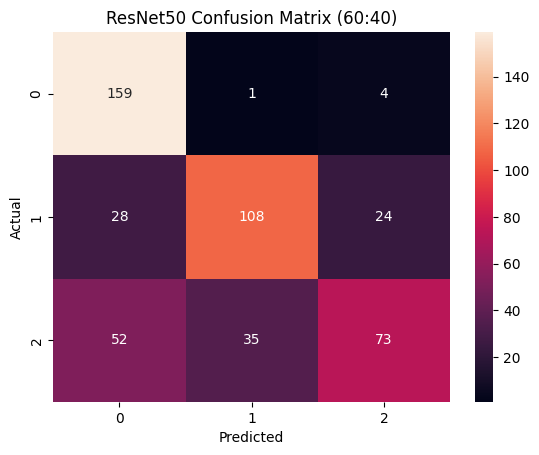

ResNet50 model saved at: /content/drive/MyDrive/Stampede Prognosia/saved_models/resnet50_stampede_60_40.h5


In [ ]:
# Model 2:ResNet50

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

# LOAD BASE MODEL
base = ResNet50(weights="imagenet",
                include_top=False,
                input_shape=(224,224,3))

# Freeze all except last 20 layers
for layer in base.layers[:-20]:
    layer.trainable = False

# BUILD MODEL
model_res = Sequential([
    base,
    GlobalAveragePooling2D(),
    Dense(256,activation="relu"),
    Dropout(0.5),
    Dense(3,activation="softmax")
])

model_res.compile(
    optimizer=Adam(0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#  TRAIN
history = model_res.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)

# ------------------- TRAIN ACCURACY -------------------
loss_train, acc_train = model_res.evaluate(train_data)
print("\nResNet50 Training Accuracy:", round(acc_train*100,2), "%")

# VALIDATION ACCURACY
loss_val, acc_val = model_res.evaluate(val_data)
print("ResNet50 Validation Accuracy:", round(acc_val*100,2), "%")

#  PREDICTIONS
y_true = val_data.classes
y_pred_probs = model_res.predict(val_data)
y_pred = np.argmax(y_pred_probs, axis=1)

# METRICS
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')
kappa = cohen_kappa_score(y_true, y_pred)

print("Accuracy:", round(accuracy*100,2), "%")
print("Precision:", round(precision,3))
print("Recall:", round(recall,3))
print("F1-Score:", round(f1,3))
print("Kappa:", round(kappa,3))

#  CONFUSION MATRIX
cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("ResNet50 Confusion Matrix (60:40)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ------------------- SAVE MODEL -------------------
MODEL_SAVE_PATH = "/content/drive/MyDrive/Stampede Prognosia/saved_models"
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

res_path = os.path.join(MODEL_SAVE_PATH, "resnet50_stampede_60_40.h5")
model_res.save(res_path)

print("ResNet50 model saved at:", res_path)



29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 323s 13s/step - accuracy: 0.3380 - loss: 1.3663 - val_accuracy: 0.4876 - val_loss: 0.9810
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 289s 13s/step - accuracy: 0.4951 - loss: 1.0046 - val_accuracy: 0.5640 - val_loss: 0.8807
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 258s 11s/step - accuracy: 0.5919 - loss: 0.8763 - val_accuracy: 0.5764 - val_loss: 0.8416
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 253s 11s/step - accuracy: 0.5817 - loss: 0.8516 - val_accuracy: 0.5971 - val_loss: 0.8607
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 249s 11s/step - accuracy: 0.5764 - loss: 0.8364 - val_accuracy: 0.5992 - val_loss: 0.8621
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 249s 11s/step - accuracy: 0.6103 - loss: 0.7790 - val_accuracy: 0.6054 - val_loss: 0.8267
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 246s 11s/step - accuracy: 0.6541 - loss: 0.8012 - val_accuracy: 0.6260 - val_loss: 0.8177
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 263s 11s/step -

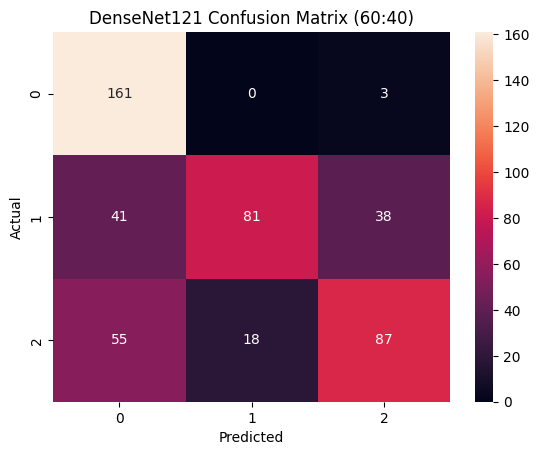

DenseNet121 model saved at: /content/drive/MyDrive/Stampede Prognosia/saved_models/densenet121_stampede_60_40.h5


In [ ]:
#MODEL 3:DenseNet121

from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

# ------------------- LOAD BASE MODEL -------------------
base = DenseNet121(weights="imagenet",
                   include_top=False,
                   input_shape=(224,224,3))

# Freeze all except last 20 layers
for layer in base.layers[:-20]:
    layer.trainable = False

# ------------------- BUILD MODEL -------------------
model_dense = Sequential([
    base,
    GlobalAveragePooling2D(),
    Dense(256,activation="relu"),
    Dropout(0.5),
    Dense(3,activation="softmax")
])

model_dense.compile(
    optimizer=Adam(0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ------------------- TRAIN -------------------
history = model_dense.fit(
    train_data,            # Already 60%
    validation_data=val_data,   # Already 40%
    epochs=20
)

# ------------------- TRAIN ACCURACY -------------------
loss_train, acc_train = model_dense.evaluate(train_data)
print("\nDenseNet121 Training Accuracy:", round(acc_train*100,2), "%")

# ------------------- VALIDATION ACCURACY -------------------
loss_val, acc_val = model_dense.evaluate(val_data)
print("DenseNet121 Validation Accuracy:", round(acc_val*100,2), "%")

# ------------------- PREDICTIONS -------------------
y_true = val_data.classes
y_pred_probs = model_dense.predict(val_data)
y_pred = np.argmax(y_pred_probs, axis=1)

# ------------------- METRICS -------------------
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')
kappa = cohen_kappa_score(y_true, y_pred)

print("Accuracy:", round(accuracy*100,2), "%")
print("Precision:", round(precision,3))
print("Recall:", round(recall,3))
print("F1-Score:", round(f1,3))
print("Kappa:", round(kappa,3))

# ------------------- CONFUSION MATRIX -------------------
cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("DenseNet121 Confusion Matrix (60:40)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ------------------- SAVE MODEL -------------------
MODEL_SAVE_PATH = "/content/drive/MyDrive/Stampede Prognosia/saved_models"
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

dense_path = os.path.join(MODEL_SAVE_PATH, "densenet121_stampede_60_40.h5")
model_dense.save(dense_path)

print("DenseNet121 model saved at:", dense_path)



16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 144s 5s/step - accuracy: 0.3293 - loss: 1.1287 - val_accuracy: 0.3306 - val_loss: 1.1406
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 119s 5s/step - accuracy: 0.3563 - loss: 1.1083 - val_accuracy: 0.3306 - val_loss: 1.1236
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 120s 5s/step - accuracy: 0.4384 - loss: 1.0744 - val_accuracy: 0.3326 - val_loss: 1.1114
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 157s 7s/step - accuracy: 0.4157 - loss: 1.0734 - val_accuracy: 0.3388 - val_loss: 1.1081
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 157s 7s/step - accuracy: 0.4439 - loss: 1.0511 - val_accuracy: 0.3388 - val_loss: 1.1118
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 117s 5s/step - accuracy: 0.4153 - loss: 1.0427 - val_accuracy: 0.3388 - val_loss: 1.1074
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 119s 5s/step - accuracy: 0.4811 - loss: 1.0271 - val_accuracy: 0.3388 - val_loss: 1.1101
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 119s 5s/step - accurac

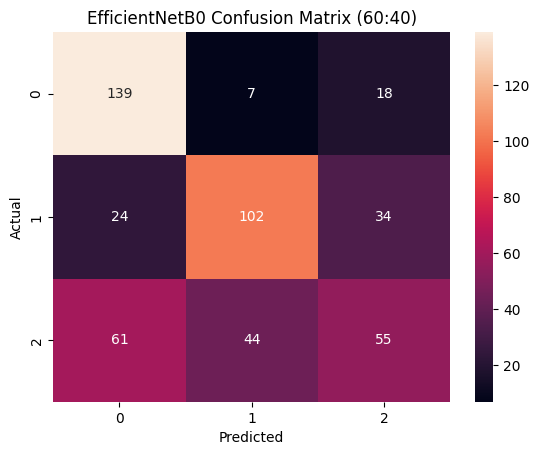

EfficientNetB0 model saved at: /content/drive/MyDrive/Stampede Prognosia/saved_models/efficientnetb0_stampede_60_40.h5


In [ ]:
#MODEL 4: EFFICIENTNETB0

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

# ------------------- LOAD BASE MODEL -------------------
base = EfficientNetB0(weights="imagenet",
                      include_top=False,
                      input_shape=(224,224,3))

# Freeze all except last 20 layers
for layer in base.layers[:-20]:
    layer.trainable = False

# ------------------- BUILD MODEL -------------------
model_eff = Sequential([
    base,
    GlobalAveragePooling2D(),
    Dense(256,activation="relu"),
    Dropout(0.5),
    Dense(3,activation="softmax")
])

model_eff.compile(
    optimizer=Adam(0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ------------------- TRAIN -------------------
history = model_eff.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)


# ------------------- VALIDATION ACCURACY -------------------
loss_val, acc_val = model_eff.evaluate(val_data)
print("EfficientNetB0 Validation Accuracy:", round(acc_val*100,2), "%")


# ------------------- PREDICTIONS -------------------
y_true = val_data.classes
y_pred_probs = model_eff.predict(val_data)
y_pred = np.argmax(y_pred_probs, axis=1)

# ------------------- METRICS -------------------
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')
kappa = cohen_kappa_score(y_true, y_pred)

print("Accuracy:", round(accuracy*100,2), "%")
print("Precision:", round(precision,3))
print("Recall:", round(recall,3))
print("F1-Score:", round(f1,3))
print("Kappa:", round(kappa,3))

# ------------------- CONFUSION MATRIX -------------------
cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("EfficientNetB0 Confusion Matrix (60:40)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ------------------- SAVE MODEL -------------------
MODEL_SAVE_PATH = "/content/drive/MyDrive/Stampede Prognosia/saved_models"
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

eff_path = os.path.join(MODEL_SAVE_PATH, "efficientnetb0_stampede_60_40.h5")
model_eff.save(eff_path)

print("EfficientNetB0 model saved at:", eff_path)



Found 731 images belonging to 3 classes.
Found 484 images belonging to 3 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 357s 15s/step - accuracy: 0.4849 - loss: 1.0011 - val_accuracy: 0.6198 - val_loss: 0.8134
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 339s 15s/step - accuracy: 0.7097 - loss: 0.6360 - val_accuracy: 0.6570 - val_loss: 0.8617
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 340s 15s/step - accuracy: 0.8531 - loss: 0.4310 - val_accuracy: 0.6694 - val_loss: 0.7646
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 339s 15s/step - accuracy: 0.8950 - loss: 0.3430 - val_accuracy: 0.6529 - val_loss: 0.8764
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 341s 15s/step - accuracy: 0.9471 - loss: 0.2386 - val_accuracy: 0.6736 - val_loss: 0.8512
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 339s 15s/step - accuracy: 0.9718 - loss: 0.1489 - val_accuracy: 0.7128 - val_loss: 0.8202
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 382s 15s/step - accuracy: 0.9808 - loss: 0.1238 - val_accuracy: 0.7169 - val_loss: 0.8131
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 337s 15s/step - accuracy: 0.9921 - loss: 0.0654 - val_accuracy: 0.

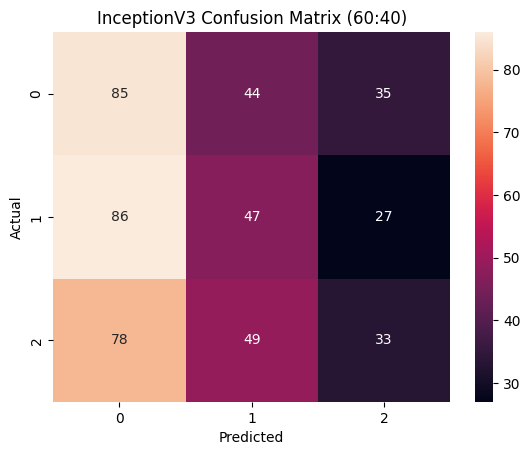

InceptionV3 model saved at: /content/drive/MyDrive/Stampede Prognosia/saved_models/inceptionv3_stampede_60_40.h5


In [ ]:
#MODEL 5: INCEPTIONV3

from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator # Import ImageDataGenerator
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

# Redefine CAT_PATH to ensure it's available
CAT_PATH = "/content/drive/MyDrive/Stampede Prognosia/categorized_images"

# Redefine datagen and load data for 60:40 split, with target_size adjusted for InceptionV3
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.4
)

train_data = datagen.flow_from_directory(
    CAT_PATH,
    target_size=(299,299),   # Changed to 299x299 for InceptionV3
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    CAT_PATH,
    target_size=(299,299),   # Changed to 299x299 for InceptionV3
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

# ------------------- LOAD BASE MODEL -------------------
base = InceptionV3(weights="imagenet",
                   include_top=False,
                   input_shape=(299,299,3))

# Freeze all except last 30 layers
for layer in base.layers[:-30]:
    layer.trainable = False

# ------------------- BUILD MODEL -------------------
model_inc = Sequential([
    base,
    GlobalAveragePooling2D(),
    Dense(256,activation="relu"),
    Dropout(0.5),
    Dense(3,activation="softmax")
])

model_inc.compile(
    optimizer=Adam(0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ------------------- TRAIN -------------------
history = model_inc.fit(
    train_data,              # Now uses correctly sized data
    validation_data=val_data,  # Now uses correctly sized data
    epochs=20
)

# ------------------- TRAIN ACCURACY -------------------
loss_train, acc_train = model_inc.evaluate(train_data)
print("\nInceptionV3 Training Accuracy:", round(acc_train*100,2), "%")

# ------------------- VALIDATION ACCURACY -------------------
loss_val, acc_val = model_inc.evaluate(val_data)
print("InceptionV3 Validation Accuracy:", round(acc_val*100,2), "%")

# ------------------- PREDICTIONS -------------------
y_true = val_data.classes
y_pred_probs = model_inc.predict(val_data)
y_pred = np.argmax(y_pred_probs, axis=1)

# ------------------- METRICS -------------------
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')
kappa = cohen_kappa_score(y_true, y_pred)

print("Accuracy:", round(accuracy*100,2), "%")
print("Precision:", round(precision,3))
print("Recall:", round(recall,3))
print("F1-Score:", round(f1,3))
print("Kappa:", round(kappa,3))

# ------------------- CONFUSION MATRIX -------------------
cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("InceptionV3 Confusion Matrix (60:40)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ------------------- SAVE MODEL -------------------
MODEL_SAVE_PATH = "/content/drive/MyDrive/Stampede Prognosia/saved_models"
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

inc_path = os.path.join(MODEL_SAVE_PATH, "inceptionv3_stampede_60_40.h5")
model_inc.save(inc_path)

print("InceptionV3 model saved at:", inc_path)

In [ ]:
# MODEL 6: VGG16

from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

# ------------------- LOAD BASE MODEL -------------------
base = VGG16(weights="imagenet",
             include_top=False,
             input_shape=(224,224,3))

# Freeze all except last 4 layers
for layer in base.layers[:-4]:
    layer.trainable = False

# ------------------- BUILD MODEL -------------------
model_vgg = Sequential([
    base,
    GlobalAveragePooling2D(),
    Dense(256,activation="relu"),
    Dropout(0.5),
    Dense(3,activation="softmax")
])

model_vgg.compile(
    optimizer=Adam(0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ------------------- TRAIN -------------------
history = model_vgg.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)

# ------------------- VALIDATION ACCURACY -------------------
loss_val, acc_val = model_vgg.evaluate(val_data)
print("VGG16 Validation Accuracy:", round(acc_val*100,2), "%")



58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 895s 39s/step - accuracy: 0.4754 - loss: 1.0446 - val_accuracy: 0.5909 - val_loss: 1.0850
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 875s 39s/step - accuracy: 0.6511 - loss: 0.7069 - val_accuracy: 0.5971 - val_loss: 0.8718
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 921s 39s/step - accuracy: 0.6922 - loss: 0.6391 - val_accuracy: 0.6736 - val_loss: 0.8136
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 872s 39s/step - accuracy: 0.7578 - loss: 0.5537 - val_accuracy: 0.6446 - val_loss: 0.8119
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 877s 39s/step - accuracy: 0.7556 - loss: 0.5512 - val_accuracy: 0.7314 - val_loss: 0.6739
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 871s 38s/step - accuracy: 0.7803 - loss: 0.4943 - val_accuracy: 0.6880 - val_loss: 0.8057
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 872s 38s/step - accuracy: 0.7903 - loss: 0.4756 - val_accuracy: 0.7603 - val_loss: 0.5625
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 885s 39s/step - accuracy: 0.7580 - loss: 0.5509 - val_accuracy: 0.

23/23 ━━━━━━━━━━━━━━━━━━━━ 494s 21s/step - accuracy: 0.8608 - loss: 0.3406

VGG16 Training Accuracy: 87.55 %
16/16 ━━━━━━━━━━━━━━━━━━━━ 313s 19s/step

Accuracy: 76.65 %
Precision: 0.776
Recall: 0.765
F1 Score: 0.765
Kappa: 0.65


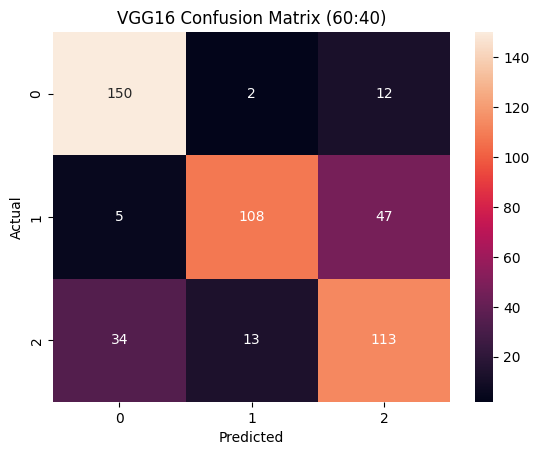

Model saved at: /content/drive/MyDrive/Stampede Prognosia/saved_models/vgg16_stampede_60_40.h5


In [ ]:
# ------------------- TRAINING ACCURACY -------------------
loss_train, acc_train = model_vgg.evaluate(train_data)
print("\nVGG16 Training Accuracy:", round(acc_train*100,2), "%")


# ------------------- PREDICTIONS -------------------
val_data.reset()
y_true = val_data.classes
y_pred_probs = model_vgg.predict(val_data)
y_pred = np.argmax(y_pred_probs, axis=1)

# ------------------- EVALUATION METRICS -------------------
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')
kappa = cohen_kappa_score(y_true, y_pred)

print("\nAccuracy:", round(accuracy*100,2), "%")
print("Precision:", round(precision,3))
print("Recall:", round(recall,3))
print("F1 Score:", round(f1,3))
print("Kappa:", round(kappa,3))

# ------------------- CONFUSION MATRIX -------------------
cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("VGG16 Confusion Matrix (60:40)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ------------------- SAVE MODEL -------------------
MODEL_SAVE_PATH = "/content/drive/MyDrive/Stampede Prognosia/saved_models"
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

model_path = os.path.join(MODEL_SAVE_PATH, "vgg16_stampede_60_40.h5")
model_vgg.save(model_path)

print("Model saved at:", model_path)


In [ ]:
#MODEL 7: MOBILENETV2

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam

base = MobileNetV2(weights="imagenet",
                   include_top=False,
                   input_shape=(224,224,3))

for layer in base.layers[:-20]:
    layer.trainable = False

model_mobilenet = Sequential([
    base,
    GlobalAveragePooling2D(),
    Dense(256, activation="relu"),
    Dropout(0.5),
    Dense(3, activation="softmax")
])

model_mobilenet.compile(
    optimizer=Adam(0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model_mobilenet.fit(train_data,
                              validation_data=val_data,
                              epochs=20)

loss, acc = model_mobilenet.evaluate(val_data)
print("\nMobileNetV2 Validation Accuracy:", round(acc*100,2), "%")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 620s 27s/step - accuracy: 0.4457 - loss: 1.1968 - val_accuracy: 0.5723 - val_loss: 1.0897
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.6794 - loss: 0.6751 - val_accuracy: 0.5455 - val_loss: 1.4255
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.8194 - loss: 0.4761 - val_accuracy: 0.5661 - val_loss: 1.3393
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.8885 - loss: 0.3382 - val_accuracy: 0.5744 - val_loss: 1.3066
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.9406 - loss: 0.2410 - val_accuracy: 0.5847 - val_loss: 1.3109
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.9345 - loss: 0.2145 - val_accuracy: 0.5785 - val_loss: 1.5008
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.9793 - loss: 0.1381 - val_accuracy: 0.5826 - val_loss: 1.5452
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.9884 - loss: 0.1018 - val_accuracy: 0.5744 - val_los

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

y_true = val_data.classes
y_pred_probs = model_mobilenet.predict(val_data)
y_pred = np.argmax(y_pred_probs, axis=1)

print("Accuracy:", round(accuracy_score(y_true, y_pred)*100,2), "%")
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

16/16 ━━━━━━━━━━━━━━━━━━━━ 16s 938ms/step
Accuracy: 33.26 %

Classification Report:

              precision    recall  f1-score   support

           0       0.35      0.56      0.43       164
           1       0.26      0.04      0.07       160
           2       0.31      0.39      0.35       160

    accuracy                           0.33       484
   macro avg       0.31      0.33      0.28       484
weighted avg       0.31      0.33      0.28       484



In [ ]:
from tensorflow.keras.models import load_model

model_vgg = load_model("/content/drive/MyDrive/Stampede Prognosia/saved_models/vgg16_stampede_60_40.h5")

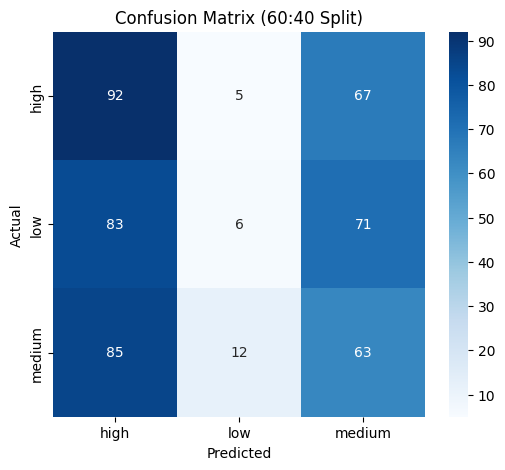

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=train_data.class_indices.keys(),
            yticklabels=train_data.class_indices.keys())

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (60:40 Split)")
plt.show()

In [ ]:
import os

# Define the directory to save the model
MODEL_SAVE_PATH = "/content/drive/MyDrive/Stampede Prognosia/saved_models"
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

# Save the MobileNetV2 model
mobilenet_model_path = os.path.join(MODEL_SAVE_PATH, "mobilenetv2_stampede_model.h5")
model_mobilenet.save(mobilenet_model_path)

print(f"MobileNetV2 model saved successfully at: {mobilenet_model_path}")

MobileNetV2 model saved successfully at: /content/drive/MyDrive/Stampede Prognosia/saved_models/mobilenetv2_stampede_model.h5


In [ ]:
from tensorflow.keras.models import load_model, Sequential
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Define the exact model architecture as it was before saving
base = MobileNetV2(weights=None, # Load weights separately
                   include_top=False,
                   input_shape=(224,224,3))

# Freeze all except last 20 layers (this was done during training, re-apply for architecture consistency)
for layer in base.layers[:-20]:
    layer.trainable = False

model_mobilenet = Sequential([
    base,
    GlobalAveragePooling2D(),
    Dense(256, activation="relu"),
    Dropout(0.5),
    Dense(3, activation="softmax")
])

# Compile the model (essential before loading weights sometimes, or for later use)
model_mobilenet.compile(
    optimizer=Adam(0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Load only the weights into the freshly built model
model_mobilenet.load_weights(
    "/content/drive/MyDrive/Stampede Prognosia/saved_models/mobilenetv2_stampede_model.h5"
)

print("MobileNetV2 model loaded successfully by recreating architecture and loading weights!")

MobileNetV2 model loaded successfully by recreating architecture and loading weights!


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

# Ensure CAT_PATH is defined if it's not globally accessible
CAT_PATH = "/content/drive/MyDrive/Stampede Prognosia/categorized_images"

# Redefine datagen and load data for 75:25 split
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.25,
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest"
)

# Create val_data for the 75:25 split
val_data = datagen.flow_from_directory(
    CAT_PATH,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

val_data.reset()   # IMPORTANT

y_true = val_data.classes
y_pred_probs = model_mobilenet.predict(val_data)
y_pred = np.argmax(y_pred_probs, axis=1)

Found 303 images belonging to 3 classes.
10/10 ━━━━━━━━━━━━━━━━━━━━ 59s 6s/step


In [ ]:
val_data.reset()   # IMPORTANT

y_true = val_data.classes
y_pred_probs = model_mobilenet.predict(val_data)
y_pred = np.argmax(y_pred_probs, axis=1)

10/10 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')
kappa = cohen_kappa_score(y_true, y_pred)

print("\nMobileNetV2 Results:")
print("Accuracy :", round(accuracy*100,2), "%")
print("Precision:", round(precision,3))
print("Recall   :", round(recall,3))
print("F1 Score :", round(f1,3))
print("Kappa    :", round(kappa,3))


MobileNetV2 Results:
Accuracy : 50.83 %
Precision: 0.672
Recall   : 0.504
F1 Score : 0.457
Kappa    : 0.258


75:25

In [ ]:
import tensorflow as tf
import numpy as np
import random

SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

In [ ]:
#Common Data Generator

from tensorflow.keras.preprocessing.image import ImageDataGenerator

CAT_PATH = "/content/drive/MyDrive/Stampede Prognosia/categorized_images"

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.25,
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest"
)

train_data = datagen.flow_from_directory(
    CAT_PATH,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=SEED
)

val_data = datagen.flow_from_directory(
    CAT_PATH,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=SEED
)

print("Training Samples:", train_data.samples)
print("Validation Samples:", val_data.samples)

Found 912 images belonging to 3 classes.
Found 303 images belonging to 3 classes.
Training Samples: 912
Validation Samples: 303


Epoch 1/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 187s 6s/step - accuracy: 0.5008 - loss: 3.5935 - val_accuracy: 0.3300 - val_loss: 4.7001
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 185s 6s/step - accuracy: 0.5995 - loss: 1.2235 - val_accuracy: 0.3300 - val_loss: 11.3149
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 186s 6s/step - accuracy: 0.6113 - loss: 0.7809 - val_accuracy: 0.3300 - val_loss: 16.7260
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 183s 6s/step - accuracy: 0.6106 - loss: 0.7790 - val_accuracy: 0.3300 - val_loss: 21.9362
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 182s 6s/step - accuracy: 0.6107 - loss: 0.8037 - val_accuracy: 0.3300 - val_loss: 28.0837
Epoch 6/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 191s 7s/step - accuracy: 0.6539 - loss: 0.7096 - val_accuracy: 0.3300 - val_loss: 33.2087
Epoch 7/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 182s 6s/step - accuracy: 0.6782 - loss: 0.6811 - val_accuracy: 0.3300 - val_loss: 36.5725
Epoch 8/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 182s 6s/step - accuracy: 0.6519 - loss: 0.7409 - val_accuracy: 0.33

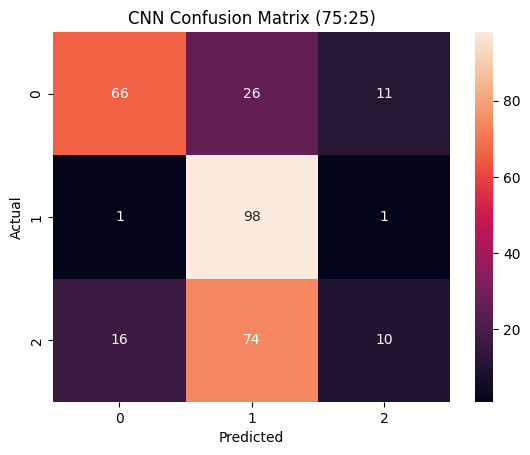

CNN model saved at: /content/drive/MyDrive/Stampede Prognosia/saved_models/cnn_stampede_75_25.h5


In [ ]:
#MODEL 1:  CNN

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

# CNN MODEL
cnn_model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256,activation='relu'),
    Dropout(0.5),
    Dense(3,activation='softmax')
])

cnn_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# TRAIN (75:25 assumed already split)
history = cnn_model.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)

# TRAINING ACCURACY
loss_train, acc_train = cnn_model.evaluate(train_data)
print("\nCNN Training Accuracy:", round(acc_train*100,2), "%")

# VALIDATION ACCURACY
loss_val, acc_val = cnn_model.evaluate(val_data)
print("CNN Validation Accuracy:", round(acc_val*100,2), "%")

# PREDICTIONS
y_true = val_data.classes
y_pred_probs = cnn_model.predict(val_data)
y_pred = np.argmax(y_pred_probs, axis=1)

# METRICS
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')
kappa = cohen_kappa_score(y_true, y_pred)

print("Accuracy:", round(accuracy*100,2), "%")
print("Precision:", round(precision,3))
print("Recall:", round(recall,3))
print("F1-Score:", round(f1,3))
print("Kappa:", round(kappa,3))

# CONFUSION MATRIX
cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("CNN Confusion Matrix (75:25)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# SAVE MODEL PERMANENTLY
MODEL_SAVE_PATH = "/content/drive/MyDrive/Stampede Prognosia/saved_models"
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

cnn_path = os.path.join(MODEL_SAVE_PATH, "cnn_stampede_75_25.h5")
cnn_model.save(cnn_path)

print("CNN model saved at:", cnn_path)



94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 449s 15s/step - accuracy: 0.4870 - loss: 1.0117 - val_accuracy: 0.4092 - val_loss: 1.0552
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 283s 10s/step - accuracy: 0.6120 - loss: 0.7739 - val_accuracy: 0.3564 - val_loss: 1.0564
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 254s 9s/step - accuracy: 0.6389 - loss: 0.7336 - val_accuracy: 0.3399 - val_loss: 1.1134
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 282s 10s/step - accuracy: 0.6649 - loss: 0.6833 - val_accuracy: 0.3399 - val_loss: 1.1713
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 255s 9s/step - accuracy: 0.7089 - loss: 0.6442 - val_accuracy: 0.3399 - val_loss: 1.2602
Epoch 6/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 252s 9s/step - accuracy: 0.6727 - loss: 0.6857 - val_accuracy: 0.3399 - val_loss: 1.1826
Epoch 7/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 253s 9s/step - accuracy: 0.6786 - loss: 0.7041 - val_accuracy: 0.3696 - val_loss: 1.2316
Epoch 8/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 253s 9s/step - accuracy: 0.7021 - loss: 0.6658 - val_accuracy: 0.3993 

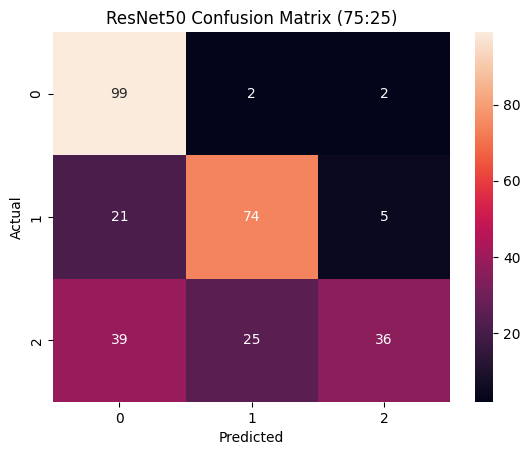

ResNet50 model saved at: /content/drive/MyDrive/Stampede Prognosia/saved_models/resnet50_stampede_75_25.h5


In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

# ------------------- LOAD BASE MODEL -------------------
base = ResNet50(weights="imagenet",
                include_top=False,
                input_shape=(224,224,3))

# Freeze all except last 20 layers
for layer in base.layers[:-20]:
    layer.trainable = False

# ------------------- BUILD MODEL -------------------
model_res = Sequential([
    base,
    GlobalAveragePooling2D(),
    Dense(256,activation="relu"),
    Dropout(0.5),
    Dense(3,activation="softmax")
])

model_res.compile(
    optimizer=Adam(0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ------------------- TRAIN -------------------
history = model_res.fit(
    train_data,              # Already 75%
    validation_data=val_data, # Already 25%
    epochs=20
)

# ------------------- TRAIN ACCURACY -------------------
loss_train, acc_train = model_res.evaluate(train_data)
print("\nResNet50 Training Accuracy:", round(acc_train*100,2), "%")

# ------------------- VALIDATION ACCURACY -------------------
loss_val, acc_val = model_res.evaluate(val_data)
print("ResNet50 Validation Accuracy:", round(acc_val*100,2), "%")

# ------------------- PREDICTIONS -------------------
y_true = val_data.classes
y_pred_probs = model_res.predict(val_data)
y_pred = np.argmax(y_pred_probs, axis=1)

# ------------------- METRICS -------------------
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')
kappa = cohen_kappa_score(y_true, y_pred)

print("Accuracy:", round(accuracy*100,2), "%")
print("Precision:", round(precision,3))
print("Recall:", round(recall,3))
print("F1-Score:", round(f1,3))
print("Kappa:", round(kappa,3))

# ------------------- CONFUSION MATRIX -------------------
cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("ResNet50 Confusion Matrix (75:25)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ------------------- SAVE MODEL -------------------
MODEL_SAVE_PATH = "/content/drive/MyDrive/Stampede Prognosia/saved_models"
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

res_path = os.path.join(MODEL_SAVE_PATH, "resnet50_stampede_75_25.h5")
model_res.save(res_path)

print("ResNet50 model saved at:", res_path)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 235s 8s/step - accuracy: 0.4066 - loss: 1.3073 - val_accuracy: 0.5116 - val_loss: 0.9813
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 210s 7s/step - accuracy: 0.5313 - loss: 0.9840 - val_accuracy: 0.5347 - val_loss: 0.9999
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 209s 7s/step - accuracy: 0.6114 - loss: 0.8400 - val_accuracy: 0.5083 - val_loss: 1.0649
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 209s 7s/step - accuracy: 0.6327 - loss: 0.7552 - val_accuracy: 0.5281 - val_loss: 1.0177
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 211s 7s/step - accuracy: 0.6538 - loss: 0.7380 - val_accuracy: 0.5512 - val_loss: 0.9982
Epoch 6/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 210s 7s/step - accuracy: 0.6666 - loss: 0.7060 - val_accuracy: 0.5545 - val_loss: 1.1133
Epoch 7/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 211s 7s/step - accuracy: 0.6877 - loss: 0.6450 - val_accuracy: 0.5215 - val_loss: 1.1866
Epoch 8/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 211s 7s/step - accurac

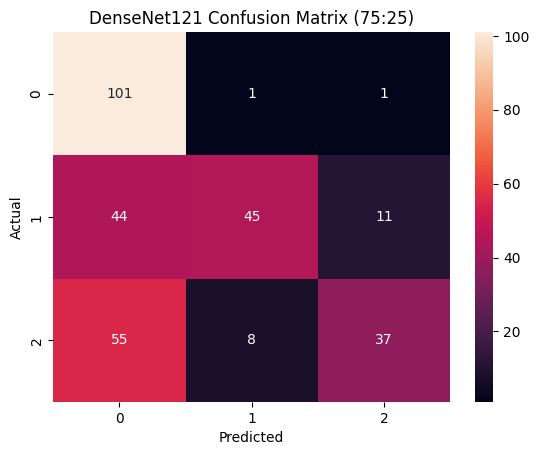

DenseNet121 model saved at: /content/drive/MyDrive/Stampede Prognosia/saved_models/densenet121_stampede_75_25.h5


In [ ]:
#Model 3: DenseNet121
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

# ------------------- LOAD BASE MODEL -------------------
base = DenseNet121(weights="imagenet",
                   include_top=False,
                   input_shape=(224,224,3))

# Freeze all except last 20 layers
for layer in base.layers[:-20]:
    layer.trainable = False

# ------------------- BUILD MODEL -------------------
model_dense = Sequential([
    base,
    GlobalAveragePooling2D(),
    Dense(256,activation="relu"),
    Dropout(0.5),
    Dense(3,activation="softmax")
])

model_dense.compile(
    optimizer=Adam(0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ------------------- TRAIN -------------------
history = model_dense.fit(
    train_data,              # Already 75%
    validation_data=val_data, # Already 25%
    epochs=20
)

# ------------------- TRAIN ACCURACY -------------------
loss_train, acc_train = model_dense.evaluate(train_data)
print("\nDenseNet121 Training Accuracy:", round(acc_train*100,2), "%")

# ------------------- VALIDATION ACCURACY -------------------
loss_val, acc_val = model_dense.evaluate(val_data)
print("DenseNet121 Validation Accuracy:", round(acc_val*100,2), "%")

# ------------------- PREDICTIONS -------------------
y_true = val_data.classes
y_pred_probs = model_dense.predict(val_data)
y_pred = np.argmax(y_pred_probs, axis=1)

# ------------------- METRICS -------------------
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')
kappa = cohen_kappa_score(y_true, y_pred)

print("Accuracy:", round(accuracy*100,2), "%")
print("Precision:", round(precision,3))
print("Recall:", round(recall,3))
print("F1-Score:", round(f1,3))
print("Kappa:", round(kappa,3))

# ------------------- CONFUSION MATRIX -------------------
cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("DenseNet121 Confusion Matrix (75:25)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ------------------- SAVE MODEL -------------------
MODEL_SAVE_PATH = "/content/drive/MyDrive/Stampede Prognosia/saved_models"
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

dense_path = os.path.join(MODEL_SAVE_PATH, "densenet121_stampede_75_25.h5")
model_dense.save(dense_path)

print("DenseNet121 model saved at:", dense_path)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 353s 12s/step - accuracy: 0.3453 - loss: 1.1206 - val_accuracy: 0.4323 - val_loss: 1.0980
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 122s 4s/step - accuracy: 0.3980 - loss: 1.0782 - val_accuracy: 0.3399 - val_loss: 1.0980
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 135s 5s/step - accuracy: 0.4404 - loss: 1.0616 - val_accuracy: 0.3399 - val_loss: 1.1141
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 123s 4s/step - accuracy: 0.4396 - loss: 1.0656 - val_accuracy: 0.3399 - val_loss: 1.1273
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 141s 4s/step - accuracy: 0.4735 - loss: 1.0204 - val_accuracy: 0.3399 - val_loss: 1.1455
Epoch 6/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 134s 5s/step - accuracy: 0.4239 - loss: 1.0188 - val_accuracy: 0.3399 - val_loss: 1.1669
Epoch 7/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 125s 4s/step - accuracy: 0.4769 - loss: 0.9884 - val_accuracy: 0.3399 - val_loss: 1.1781
Epoch 8/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 121s 4s/step - accuracy: 0.4638 - loss: 0.9776 - val_accuracy: 0.3399 - 

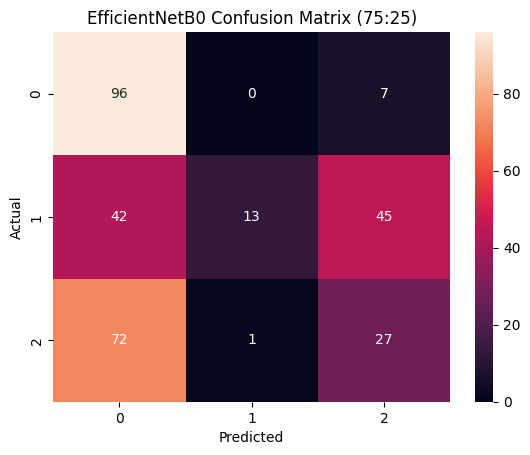

EfficientNetB0 model saved at: /content/drive/MyDrive/Stampede Prognosia/saved_models/efficientnetb0_stampede_75_25.h5


In [ ]:
#MODEL 4 EFFICIENTNETB0

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

# ------------------- LOAD BASE MODEL -------------------
base = EfficientNetB0(weights="imagenet",
                      include_top=False,
                      input_shape=(224,224,3))

# Freeze all except last 20 layers
for layer in base.layers[:-20]:
    layer.trainable = False

# ------------------- BUILD MODEL -------------------
model_eff = Sequential([
    base,
    GlobalAveragePooling2D(),
    Dense(256,activation="relu"),
    Dropout(0.5),
    Dense(3,activation="softmax")
])

model_eff.compile(
    optimizer=Adam(0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ------------------- TRAIN -------------------
history = model_eff.fit(
    train_data,               # Already 75%
    validation_data=val_data, # Already 25%
    epochs=20
)

# ------------------- TRAIN ACCURACY -------------------
loss_train, acc_train = model_eff.evaluate(train_data)
print("\nEfficientNetB0 Training Accuracy:", round(acc_train*100,2), "%")

# ------------------- VALIDATION ACCURACY -------------------
loss_val, acc_val = model_eff.evaluate(val_data)
print("EfficientNetB0 Validation Accuracy:", round(acc_val*100,2), "%")

# ------------------- PREDICTIONS -------------------
y_true = val_data.classes
y_pred_probs = model_eff.predict(val_data)
y_pred = np.argmax(y_pred_probs, axis=1)

# ------------------- METRICS -------------------
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')
kappa = cohen_kappa_score(y_true, y_pred)

print("Accuracy:", round(accuracy*100,2), "%")
print("Precision:", round(precision,3))
print("Recall:", round(recall,3))
print("F1-Score:", round(f1,3))
print("Kappa:", round(kappa,3))

# ------------------- CONFUSION MATRIX -------------------
cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("EfficientNetB0 Confusion Matrix (75:25)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ------------------- SAVE MODEL -------------------
MODEL_SAVE_PATH = "/content/drive/MyDrive/Stampede Prognosia/saved_models"
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

eff_path = os.path.join(MODEL_SAVE_PATH, "efficientnetb0_stampede_75_25.h5")
model_eff.save(eff_path)

print("EfficientNetB0 model saved at:", eff_path)



Found 912 images belonging to 3 classes.
Found 303 images belonging to 3 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 395s 13s/step - accuracy: 0.5258 - loss: 0.9394 - val_accuracy: 0.5611 - val_loss: 0.9556
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 373s 13s/step - accuracy: 0.6768 - loss: 0.6751 - val_accuracy: 0.5380 - val_loss: 1.0542
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 429s 15s/step - accuracy: 0.7191 - loss: 0.6284 - val_accuracy: 0.6040 - val_loss: 0.9060
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 375s 13s/step - accuracy: 0.7470 - loss: 0.5903 - val_accuracy: 0.5743 - val_loss: 0.9647
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 430s 15s/step - accuracy: 0.7356 - loss: 0.5762 - val_accuracy: 0.5512 - val_loss: 1.2367
Epoch 6/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 430s 15s/step - accuracy: 0.7259 - loss: 0.5858 - val_accuracy: 0.5545 - val_loss: 1.2566
Epoch 7/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 373s 13s/step - accuracy: 0.7614 - loss: 0.5300 - val_accuracy: 0.5512 - val_loss: 1.2168
Epoch 8/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 371s 13s/step - accuracy: 0.7723 - loss: 0.5178 - val_accuracy: 0.

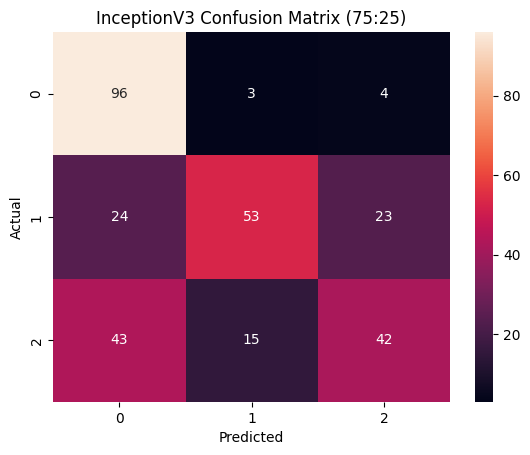

InceptionV3 model saved at: /content/drive/MyDrive/Stampede Prognosia/saved_models/inceptionv3_stampede_75_25.h5


In [ ]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Redefine CAT_PATH to ensure it's available
CAT_PATH = "/content/drive/MyDrive/Stampede Prognosia/categorized_images"

# Redefine datagen and load data for 75:25 split, with target_size adjusted for InceptionV3
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.25,
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest"
)

train_data = datagen.flow_from_directory(
    CAT_PATH,
    target_size=(299,299),   # Adjusted to 299x299 for InceptionV3
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_data = datagen.flow_from_directory(
    CAT_PATH,
    target_size=(299,299),   # Adjusted to 299x299 for InceptionV3
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)


# ------------------- LOAD BASE MODEL -------------------
base = InceptionV3(weights="imagenet",
                   include_top=False,
                   input_shape=(299,299,3))

# Freeze all except last 30 layers
for layer in base.layers[:-30]:
    layer.trainable = False

# ------------------- BUILD MODEL -------------------
model_inc = Sequential([
    base,
    GlobalAveragePooling2D(),
    Dense(256,activation="relu"),
    Dropout(0.5),
    Dense(3,activation="softmax")
])

model_inc.compile(
    optimizer=Adam(0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ------------------- TRAIN -------------------
history = model_inc.fit(
    train_data,               # Already 75%
    validation_data=val_data, # Already 25%
    epochs=20
)

# ------------------- TRAIN ACCURACY -------------------
loss_train, acc_train = model_inc.evaluate(train_data)
print("\nInceptionV3 Training Accuracy:", round(acc_train*100,2), "%")

# ------------------- VALIDATION ACCURACY -------------------
loss_val, acc_val = model_inc.evaluate(val_data)
print("InceptionV3 Validation Accuracy:", round(acc_val*100,2), "%")

# ------------------- PREDICTIONS -------------------
y_true = val_data.classes
y_pred_probs = model_inc.predict(val_data)
y_pred = np.argmax(y_pred_probs, axis=1)

# ------------------- METRICS -------------------
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')
kappa = cohen_kappa_score(y_true, y_pred)

print("Accuracy:", round(accuracy*100,2), "%")
print("Precision:", round(precision,3))
print("Recall:", round(recall,3))
print("F1-Score:", round(f1,3))
print("Kappa:", round(kappa,3))

# ------------------- CONFUSION MATRIX -------------------
cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("InceptionV3 Confusion Matrix (75:25)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ------------------- SAVE MODEL -------------------
MODEL_SAVE_PATH = "/content/drive/MyDrive/Stampede Prognosia/saved_models"
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

inc_path = os.path.join(MODEL_SAVE_PATH, "inceptionv3_stampede_75_25.h5")
model_inc.save(inc_path)

print("InceptionV3 model saved at:", inc_path)

Found 912 images belonging to 3 classes.
Found 303 images belonging to 3 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 97s 3s/step - accuracy: 0.4504 - loss: 1.1010 - val_accuracy: 0.5248 - val_loss: 1.1309
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 137s 3s/step - accuracy: 0.6148 - loss: 0.7927 - val_accuracy: 0.5215 - val_loss: 1.4745
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 85s 3s/step - accuracy: 0.6767 - loss: 0.6991 - val_accuracy: 0.5017 - val_loss: 1.7021
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.6763 - loss: 0.6294 - val_accuracy: 0.4818 - val_loss: 1.8081
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.7416 - loss: 0.5776 - val_accuracy: 0.5281 - val_loss: 1.6835
Epoch 6/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 85s 3s/step - accuracy: 0.7387 - loss: 0.6032 - val_accuracy: 0.4917 - val_loss: 2.0557
Epoch 7/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.7754 - loss: 0.5452 - val_accuracy: 0.4719 - val_loss: 2.1566
Epoch 8/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 83s 3s/step - accuracy: 0.7706 - loss: 0.5228 - val_accuracy: 0.5017 - val_loss

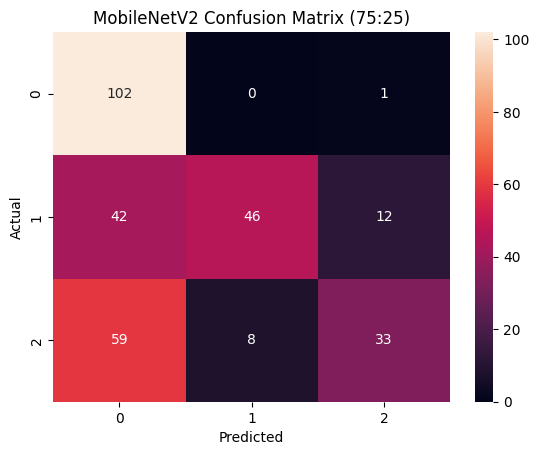

MobileNetV2 model saved at: /content/drive/MyDrive/Stampede Prognosia/saved_models/mobilenetv2_stampede_75_25.h5


In [ ]:
#Model 7:MobileNetV2

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Redefine CAT_PATH to ensure it's available
CAT_PATH = "/content/drive/MyDrive/Stampede Prognosia/categorized_images"

# Redefine datagen and load data for 75:25 split, with target_size adjusted for MobileNetV2
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.25,
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest"
)

train_data = datagen.flow_from_directory(
    CAT_PATH,
    target_size=(224,224),   # Adjusted to 224x224 for MobileNetV2
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_data = datagen.flow_from_directory(
    CAT_PATH,
    target_size=(224,224),   # Adjusted to 224x224 for MobileNetV2
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

# ------------------- LOAD BASE MODEL -------------------
base = MobileNetV2(weights="imagenet",
                   include_top=False,
                   input_shape=(224,224,3))

# Freeze all except last 20 layers
for layer in base.layers[:-20]:
    layer.trainable = False

# ------------------- BUILD MODEL -------------------
model_mobilenet = Sequential([
    base,
    GlobalAveragePooling2D(),
    Dense(256, activation="relu"),
    Dropout(0.5),
    Dense(3, activation="softmax")
])

model_mobilenet.compile(
    optimizer=Adam(0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ------------------- TRAIN -------------------
history = model_mobilenet.fit(
    train_data,               # Already 75%
    validation_data=val_data, # Already 25%
    epochs=20
)

# ------------------- TRAIN ACCURACY -------------------
loss_train, acc_train = model_mobilenet.evaluate(train_data)
print("\nMobileNetV2 Training Accuracy:", round(acc_train*100,2), "%")

# ------------------- VALIDATION ACCURACY -------------------
loss_val, acc_val = model_mobilenet.evaluate(val_data)
print("MobileNetV2 Validation Accuracy:", round(acc_val*100,2), "%")

# ------------------- PREDICTIONS -------------------
y_true = val_data.classes
y_pred_probs = model_mobilenet.predict(val_data)
y_pred = np.argmax(y_pred_probs, axis=1)

# ------------------- METRICS -------------------
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')
kappa = cohen_kappa_score(y_true, y_pred)

print("Accuracy:", round(accuracy*100,2), "%")
print("Precision:", round(precision,3))
print("Recall:", round(recall,3))
print("F1-Score:", round(f1,3))
print("Kappa:", round(kappa,3))

# ------------------- CONFUSION MATRIX -------------------
cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("MobileNetV2 Confusion Matrix (75:25)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ------------------- SAVE MODEL -------------------
MODEL_SAVE_PATH = "/content/drive/MyDrive/Stampede Prognosia/saved_models"
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

mobile_path = os.path.join(MODEL_SAVE_PATH, "mobilenetv2_stampede_75_25.h5")
model_mobilenet.save(mobile_path)

print("MobileNetV2 model saved at:", mobile_path)


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 651s 22s/step - accuracy: 0.4935 - loss: 1.0056 - val_accuracy: 0.5380 - val_loss: 1.1339
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 584s 20s/step - accuracy: 0.6592 - loss: 0.6924 - val_accuracy: 0.6007 - val_loss: 1.2937
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 553s 19s/step - accuracy: 0.7001 - loss: 0.6108 - val_accuracy: 0.6601 - val_loss: 0.8300
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 553s 19s/step - accuracy: 0.7365 - loss: 0.5944 - val_accuracy: 0.6832 - val_loss: 0.7275
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 558s 19s/step - accuracy: 0.7643 - loss: 0.5100 - val_accuracy: 0.6601 - val_loss: 0.7966
Epoch 6/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 560s 19s/step - accuracy: 0.7914 - loss: 0.4934 - val_accuracy: 0.7096 - val_loss: 0.6339
Epoch 7/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 555s 19s/step - accuracy: 0.8319 - loss: 0.4478 - val_accuracy: 0.6964 - val_loss: 0.6812
Epoch 8/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 552s 19s/step - accuracy: 0.8079 - loss: 0.4825 - val_accuracy: 0.

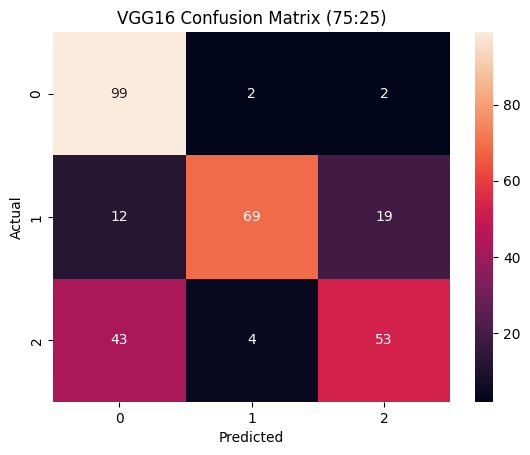

Model saved at: /content/drive/MyDrive/Stampede Prognosia/saved_models/vgg16_stampede_75_25.h5


In [ ]:
# MODEL 6: VGG16 (75:25 split)

from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

# ------------------- LOAD BASE MODEL -------------------
base = VGG16(weights="imagenet",
             include_top=False,
             input_shape=(224,224,3))

# Freeze all except last 4 layers
for layer in base.layers[:-4]:
    layer.trainable = False

# ------------------- BUILD MODEL -------------------
model_vgg = Sequential([
    base,
    GlobalAveragePooling2D(),
    Dense(256,activation="relu"),
    Dropout(0.5),
    Dense(3,activation="softmax")
])

model_vgg.compile(
    optimizer=Adam(0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ------------------- TRAIN -------------------
history = model_vgg.fit(
    train_data,               # Already 75%
    validation_data=val_data, # Already 25%
    epochs=20
)

# ------------------- TRAINING ACCURACY -------------------
loss_train, acc_train = model_vgg.evaluate(train_data)
print("\nVGG16 Training Accuracy:", round(acc_train*100,2), "%")

# ------------------- VALIDATION ACCURACY -------------------
loss_val, acc_val = model_vgg.evaluate(val_data)
print("VGG16 Validation Accuracy:", round(acc_val*100,2), "%")

# ------------------- PREDICTIONS -------------------
val_data.reset()
y_true = val_data.classes
y_pred_probs = model_vgg.predict(val_data)
y_pred = np.argmax(y_pred_probs, axis=1)

# ------------------- EVALUATION METRICS -------------------
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')
kappa = cohen_kappa_score(y_true, y_pred)

print("\nAccuracy:", round(accuracy*100,2), "%")
print("Precision:", round(precision,3))
print("Recall:", round(recall,3))
print("F1 Score:", round(f1,3))
print("Kappa:", round(kappa,3))

# ------------------- CONFUSION MATRIX -------------------
cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("VGG16 Confusion Matrix (75:25)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ------------------- SAVE MODEL -------------------
MODEL_SAVE_PATH = "/content/drive/MyDrive/Stampede Prognosia/saved_models"
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

model_path = os.path.join(MODEL_SAVE_PATH, "vgg16_stampede_75_25.h5")
model_vgg.save(model_path)

print("Model saved at:", model_path)

Model Ready


Choose option:
1 → Upload Image
2 → Paste Image URL
3 → Exit
Enter choice: 1


Saving test 1.jpeg to test 1 (5).jpeg


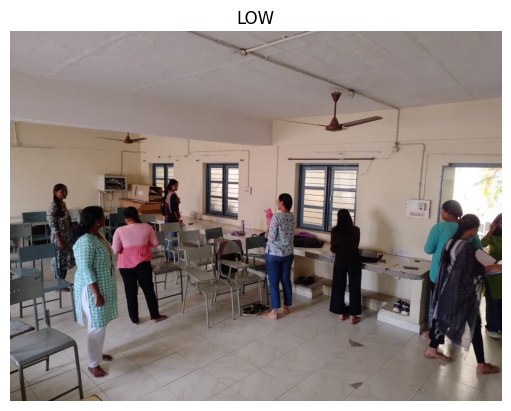


Choose option:
1 → Upload Image
2 → Paste Image URL
3 → Exit
Enter choice: 1


Saving 7.jpg to 7 (2).jpg


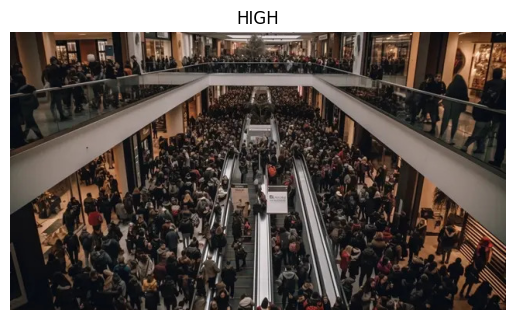


Choose option:
1 → Upload Image
2 → Paste Image URL
3 → Exit
Enter choice: 1


Saving 8.jpg to 8 (2).jpg


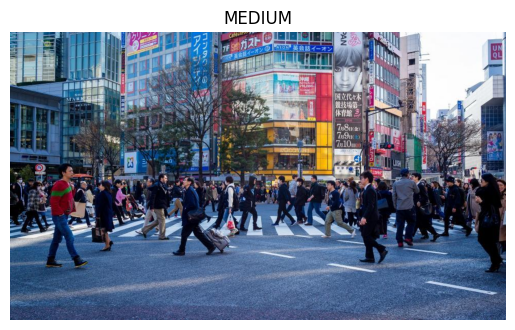


Choose option:
1 → Upload Image
2 → Paste Image URL
3 → Exit
Enter choice: 1


Saving 1.webp to 1.webp


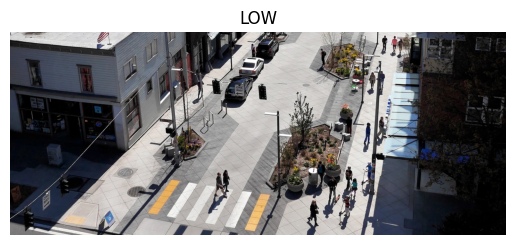


Choose option:
1 → Upload Image
2 → Paste Image URL
3 → Exit
Enter choice: 1


Saving 3.jpg to 3 (1).jpg


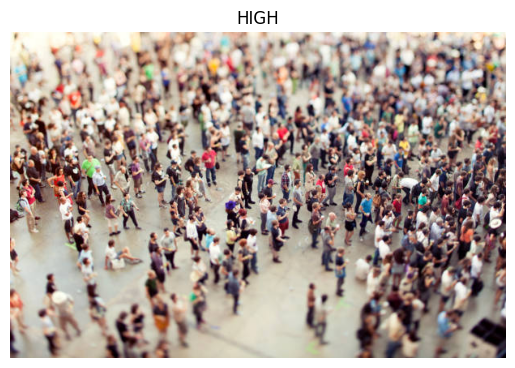


Choose option:
1 → Upload Image
2 → Paste Image URL
3 → Exit
Enter choice: 3
Exiting...


In [ ]:
# IMPORTS

import numpy as np
import cv2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from google.colab import files
from PIL import Image
import requests
from io import BytesIO
import os

# LOAD MODEL

MODEL_PATH = "/content/drive/MyDrive/Stampede Prognosia/saved_models/vgg16_stampede_60_40.h5"

base = VGG16(weights="imagenet",
             include_top=False,
             input_shape=(224,224,3))

for layer in base.layers[:-4]:
    layer.trainable = False

model = Sequential([
    base,
    GlobalAveragePooling2D(),
    Dense(256, activation="relu"),
    Dropout(0.5),
    Dense(3, activation="softmax")
])

model.compile(
    optimizer=Adam(0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.load_weights(MODEL_PATH)
print("Model Ready\n")

#CLASS MAP

CAT_PATH = "/content/drive/MyDrive/Stampede Prognosia/categorized_images"

classes = sorted(os.listdir(CAT_PATH))   # ['high','low','medium']
class_indices = {cls: idx for idx, cls in enumerate(classes)}
class_map = {v: k.upper() for k, v in class_indices.items()}

# PREPROCESS

def preprocess_image(img):
    img = cv2.resize(img, (224,224))
    img = img / 255.0
    img = np.reshape(img, (1,224,224,3))
    return img

#  PREDICT
def predict_image(img):
    processed = preprocess_image(img)
    pred = model.predict(processed, verbose=0)

    class_index = np.argmax(pred)
    return class_map[class_index]

# MAIN LOOP
while True:
    print("\nChoose option:")
    print("1 → Upload Image")
    print("2 → Paste Image URL")
    print("3 → Exit")

    choice = input("Enter choice: ")


    # OPTION 1: UPLOAD
    if choice == "1":
        uploaded = files.upload()

        for file in uploaded.keys():
            img = cv2.imread(file)

            if img is None:
                print("Error loading image")
                continue

            label = predict_image(img)

            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            plt.title(label)
            plt.axis("off")
            plt.show()

    # OPTION 2: URL
    elif choice == "2":
        url = input("Paste image URL: ")

        try:
            response = requests.get(url)
            img = Image.open(BytesIO(response.content))
            img = np.array(img)
            img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

            label = predict_image(img)

            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            plt.title(label)
            plt.axis("off")
            plt.show()

        except:
            print("Invalid URL or image error")

    # EXIT
    elif choice == "3":
        print("Exiting...")
        break

    else:
        print("Invalid choice")